In [1]:
# %% ===================== CELL 1: IMPORTS, CONFIG, PATHS =====================
# Зачем: импорт библиотек + все ключевые настройки эксперимента + пути/кеш/артефакты.
import os
import gc
import json
import time
import math
import pickle
import random
import warnings
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    fbeta_score,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# -------- reproducibility --------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -------- core config --------
BAR_FREQ = "15min"
BAR_DELTA = pd.Timedelta(minutes=15)
LOOKBACK_DAYS = 365
WARMUP_DAYS = 30
WARMUP_BARS = WARMUP_DAYS * 24 * 4
LABEL_HORIZON_BARS = 10
PUMP_MIN_FWD_RETURN = 0.05

UNIVERSE_SIZE = 100
CONTEXT_SYMBOL = "BTCUSDT"

TRAIN_DAYS = 180
TEST_DAYS = 30
STEP_DAYS = 30
PURGE_GAP_BARS = 10
CALIB_FRAC = 0.20

FEE_IN_PCT = 0.0010
FEE_OUT_PCT = 0.0010
SLIPPAGE_PCT = 0.0005

MAX_POS = 5
RANK_K_DEFAULT = 20

THRESH_GRID = np.round(np.linspace(0.50, 0.99, 50), 2)
SENS_THRESHOLDS = [0.60, 0.70, 0.80, 0.90]
SENS_KS = [5, 10, 20]

BYBIT_BASE_URL = "https://api.bybit.com"
REQUEST_TIMEOUT = 30
REQUEST_RETRIES = 5
REQUEST_SLEEP = 0.08
SYMBOL_SLEEP = 0.35

USE_OI_BACKTEST = False  # инфраструктура есть, в бектест по умолчанию не используем

# -------- TRAMA config --------
TRAMA_CONFIG = {
    "15m": [3, 9, 20, 30],
    "30m": [10, 50],
    "60m": [20, 50, 100],
}
PLOT_TRAMA_KEYS = ["trama_15m_20", "trama_15m_30", "trama_60m_50"]

# -------- folders --------
ROOT = Path(".")
DATA_DIR = ROOT / "data"
CACHE_DIR = DATA_DIR / "cache"
KLINES_DIR = CACHE_DIR / "klines_spot_15m"
FEATURES_DIR = CACHE_DIR / "features"
DATASET_DIR = CACHE_DIR / "datasets"
LIVE_DIR = CACHE_DIR / "live"
ARTIFACTS_DIR = ROOT / "artifacts"
CHARTS_DIR = ROOT / "charts"

for p in [DATA_DIR, CACHE_DIR, KLINES_DIR, FEATURES_DIR, DATASET_DIR, LIVE_DIR, ARTIFACTS_DIR, CHARTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DATASET_PATH = DATASET_DIR / "pump_start_dataset.parquet"
UNIVERSE_PATH = DATASET_DIR / "spot_universe_top100.parquet"
FOLD_METRICS_PATH = ARTIFACTS_DIR / "fold_metrics.csv"
OOS_PREDS_PATH = ARTIFACTS_DIR / "oos_predictions.parquet"
IMPORTANCE_PATH = ARTIFACTS_DIR / "feature_importance_by_fold.csv"
IMPORTANCE_STABILITY_PATH = ARTIFACTS_DIR / "feature_importance_stability.csv"
BACKTEST_TRADES_PATH = ARTIFACTS_DIR / "backtest_trades.parquet"
BACKTEST_EQUITY_PATH = ARTIFACTS_DIR / "backtest_equity.parquet"
BACKTEST_STOPLOG_PATH = ARTIFACTS_DIR / "backtest_stop_log.parquet"

# -------- feature name helpers --------
BASE_FEATURES = [
    "atr20_pct",
    "ret_1",
    "ret_4",
    "ret_1_atr",
    "range",
    "body",
    "vol",
    "vol_z",
    "vwap96",
    "vwap_dist",
]

def get_trama_feature_names():
    out = []
    for tf_name, lengths in TRAMA_CONFIG.items():
        for ln in lengths:
            out += [f"dist_{tf_name}_{ln}", f"cross12_{tf_name}_{ln}"]
    return out

TRAMA_FEATURES = get_trama_feature_names()

BTC_CONTEXT_FEATURES = [
    "btc_atr20_pct",
    "btc_ret_1",
    "btc_ret_4",
    "btc_ret_1_atr",
    "btc_vol_z",
    "btc_vwap_dist",
]

MODEL_FEATURES = BASE_FEATURES + TRAMA_FEATURES + BTC_CONTEXT_FEATURES

AUX_COLUMNS = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "turnover",
    "atr20_price",
    "low20_min",
    "fwd_max_ret10",
    "dollar_vol",
    "dollar_vol_96",
    "vwap96",
    "next_open",
    "next_timestamp",
    "warm_ready",
]

print(f"MODEL_FEATURES: {len(MODEL_FEATURES)}")
print("Data dir:", DATASET_PATH.resolve())

MODEL_FEATURES: 34
Data dir: /Users/pavel/data/cache/datasets/pump_start_dataset.parquet


In [2]:
# %% ===================== CELL 2 (FIXED): HTTP CLIENT + API KEYS PLACEHOLDER =====================
# ВСТАВЬ СЮДА СВОИ КЛЮЧИ (Bybit API V5)
# Важно: для этого ноутбука ключи не нужны (мы качаем публичные данные),
# но заготовка оставлена, чтобы потом легко подключить приватные эндпоинты.
BYBIT_API_KEY = "wDb7s7sA591dZh3qwn"       # <-- сюда вставь API Key
BYBIT_API_SECRET = "2QOElqxZO4Sagd3tIa6oG54guE1qAW6CHZN4"    # <-- сюда вставь API Secret

# Если хочешь, можно хранить ключи в env:
# export BYBIT_API_KEY="..."
# export BYBIT_API_SECRET="..."
USE_ENV_KEYS = True

import time
import hmac
import hashlib
import json
import requests
import pandas as pd
import numpy as np

class BybitHTTP:
    def __init__(
        self,
        base_url: str = BYBIT_BASE_URL,
        timeout: int = REQUEST_TIMEOUT,
        retries: int = REQUEST_RETRIES,
        sleep_s: float = REQUEST_SLEEP,
        api_key: str | None = None,
        api_secret: str | None = None,
    ):
        self.base_url = base_url.rstrip("/")
        self.timeout = timeout
        self.retries = retries
        self.sleep_s = sleep_s

        if USE_ENV_KEYS:
            api_key = os.getenv("BYBIT_API_KEY", api_key)
            api_secret = os.getenv("BYBIT_API_SECRET", api_secret)

        self.api_key = api_key or ""
        self.api_secret = api_secret or ""

        self.session = requests.Session()

    # ---------- signature helpers (для приватных эндпоинтов) ----------
    def _ts_ms(self) -> str:
        return str(int(time.time() * 1000))

    def _sign(self, ts_ms: str, recv_window: str, payload_str: str) -> str:
        # Bybit V5: sign = HMAC_SHA256(secret, ts + api_key + recv_window + payload_str)
        msg = (ts_ms + self.api_key + recv_window + payload_str).encode("utf-8")
        return hmac.new(self.api_secret.encode("utf-8"), msg, hashlib.sha256).hexdigest()

    def _headers_private(self, payload_str: str, recv_window: str = "5000") -> dict:
        ts_ms = self._ts_ms()
        sign = self._sign(ts_ms, recv_window, payload_str)
        return {
            "X-BAPI-API-KEY": self.api_key,
            "X-BAPI-SIGN": sign,
            "X-BAPI-SIGN-TYPE": "2",
            "X-BAPI-TIMESTAMP": ts_ms,
            "X-BAPI-RECV-WINDOW": recv_window,
            "Content-Type": "application/json",
        }

    # ---------- request wrappers ----------
    def _get(self, path: str, params: dict | None = None, private: bool = False) -> dict:
        url = f"{self.base_url}{path}"
        params = params or {}
        last_err = None

        # Для подписи GET нужно payload_str = querystring (отсортированный), но
        # пока приватные GET в ноутбуке не используем. Заготовка на будущее:
        payload_str = ""
        headers = self._headers_private(payload_str) if private else {}

        for attempt in range(1, self.retries + 1):
            try:
                resp = self.session.get(url, params=params, headers=headers, timeout=self.timeout)
                if resp.status_code in (429, 500, 502, 503, 504):
                    raise RuntimeError(f"HTTP {resp.status_code}: {resp.text[:300]}")
                resp.raise_for_status()
                data = resp.json()
                if data.get("retCode") != 0:
                    raise RuntimeError(f"Bybit retCode={data.get('retCode')} retMsg={data.get('retMsg')}")
                time.sleep(self.sleep_s)
                return data
            except Exception as e:
                last_err = e
                sleep_for = min(2.0 * attempt, 10.0)
                print(f"[retry {attempt}/{self.retries}] GET {path} params={params} err={e}")
                time.sleep(sleep_for)

        raise RuntimeError(f"GET failed after retries: {path} | {last_err}")

    def _post(self, path: str, body: dict, private: bool = True) -> dict:
        url = f"{self.base_url}{path}"
        last_err = None

        payload_str = json.dumps(body, separators=(",", ":"), ensure_ascii=False)
        headers = self._headers_private(payload_str) if private else {"Content-Type": "application/json"}

        for attempt in range(1, self.retries + 1):
            try:
                resp = self.session.post(url, data=payload_str.encode("utf-8"), headers=headers, timeout=self.timeout)
                if resp.status_code in (429, 500, 502, 503, 504):
                    raise RuntimeError(f"HTTP {resp.status_code}: {resp.text[:300]}")
                resp.raise_for_status()
                data = resp.json()
                if data.get("retCode") != 0:
                    raise RuntimeError(f"Bybit retCode={data.get('retCode')} retMsg={data.get('retMsg')}")
                time.sleep(self.sleep_s)
                return data
            except Exception as e:
                last_err = e
                sleep_for = min(2.0 * attempt, 10.0)
                print(f"[retry {attempt}/{self.retries}] POST {path} body={body} err={e}")
                time.sleep(sleep_for)

        raise RuntimeError(f"POST failed after retries: {path} | {last_err}")

    # ---------- public endpoints ----------
    def get_instruments_info(self, category: str = "spot") -> list[dict]:
        data = self._get("/v5/market/instruments-info", {"category": category}, private=False)
        return data["result"]["list"]

    def get_tickers(self, category: str = "spot", symbol: str | None = None) -> list[dict]:
        params = {"category": category}
        if symbol:
            params["symbol"] = symbol
        data = self._get("/v5/market/tickers", params, private=False)
        return data["result"]["list"]

    def get_kline(
        self,
        category: str,
        symbol: str,
        interval: str,
        start: int | None = None,
        end: int | None = None,
        limit: int = 1000,
    ) -> list[list[str]]:
        params = {"category": category, "symbol": symbol, "interval": interval, "limit": limit}
        if start is not None:
            params["start"] = int(start)
        if end is not None:
            params["end"] = int(end)
        data = self._get("/v5/market/kline", params, private=False)
        return data["result"]["list"]

    def get_open_interest(
        self,
        symbol: str,
        interval_time: str = "15min",
        category: str = "linear",
        start_time: int | None = None,
        end_time: int | None = None,
        limit: int = 200,
        cursor: str | None = None,
    ) -> dict:
        params = {"category": category, "symbol": symbol, "intervalTime": interval_time, "limit": limit}
        if start_time is not None:
            params["startTime"] = int(start_time)
        if end_time is not None:
            params["endTime"] = int(end_time)
        if cursor:
            params["cursor"] = cursor
        data = self._get("/v5/market/open-interest", params, private=False)
        return data["result"]

    def get_orderbook(self, symbol: str, category: str = "spot", limit: int = 50) -> dict:
        data = self._get("/v5/market/orderbook", {"category": category, "symbol": symbol, "limit": limit}, private=False)
        return data["result"]

    # ---------- private examples (потом пригодится) ----------
    # ВНИМАНИЕ: ниже примеры. Они НЕ используются в бектесте.
    def get_wallet_balance(self, account_type: str = "UNIFIED", coin: str | None = None) -> dict:
        if not self.api_key or not self.api_secret:
            raise RuntimeError("API keys are empty. Fill BYBIT_API_KEY and BYBIT_API_SECRET.")
        params = {"accountType": account_type}
        if coin:
            params["coin"] = coin
        # V5 wallet balance — это private GET: /v5/account/wallet-balance
        # Здесь оставлено как заготовка: в _get private=True потребуется корректный payload_str для querystring.
        data = self._get("/v5/account/wallet-balance", params=params, private=True)
        return data["result"]


def to_utc_ts(x) -> pd.Timestamp:
    ts = pd.Timestamp(x)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")
    return ts

def floor_bar_utc(ts: pd.Timestamp, freq: str = BAR_FREQ) -> pd.Timestamp:
    return to_utc_ts(ts).floor(freq)

def safe_num(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default

def ensure_utc_index(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("Index must be DatetimeIndex")
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    else:
        df.index = df.index.tz_convert("UTC")
    return df.sort_index()

# init client (keys optional)
client = BybitHTTP(api_key=BYBIT_API_KEY, api_secret=BYBIT_API_SECRET)
print("Bybit client ready. Keys set:", bool(client.api_key) and bool(client.api_secret))

Bybit client ready. Keys set: True


In [3]:
# %% ===================== CELL 3 (FIXED): BUILD SPOT UNIVERSE (TOP-N BY TURNOVER24H, NO STABLES, ADD PAXG) =====================
# Что делаем:
# 1) Берём spot тикеры и инструменты
# 2) Оставляем только *USDT пары* (quoteCoin=USDT)
# 3) Убираем стейблкоины и XAUT
# 4) Гарантируем, что BTCUSDT и PAXGUSDT есть в списке

# --- фильтры (можешь расширять) ---
STABLE_BASE_COINS = {
    "USDC", "USDT", "DAI", "FDUSD", "TUSD", "USDE", "USDP", "USDD", "BUSD",
    "FRAX", "LUSD", "PYUSD", "GUSD", "USDJ", "EURC", "USDS"
}
# Явный blacklist по символам (точечно)
SYMBOL_BLACKLIST = {
    "USDCUSDT",   # стейбл
    "XAUTUSDT",   # золото - убираем
}
# Символы, которые должны быть в universe всегда
FORCE_INCLUDE = {"BTCUSDT", "PAXGUSDT"}

def build_spot_universe(client: BybitHTTP, universe_size: int = UNIVERSE_SIZE, force_refresh: bool = False) -> pd.DataFrame:
    if UNIVERSE_PATH.exists() and not force_refresh:
        df_uni = pd.read_parquet(UNIVERSE_PATH)
        df_uni["symbol"] = df_uni["symbol"].astype(str)
        return df_uni

    print("Fetching instruments info...")
    instruments = pd.DataFrame(client.get_instruments_info(category="spot"))
    print("Fetching tickers...")
    tickers = pd.DataFrame(client.get_tickers(category="spot"))

    if instruments.empty or tickers.empty:
        raise RuntimeError("Failed to build universe")

    use_cols_inst = [c for c in ["symbol", "status", "baseCoin", "quoteCoin"] if c in instruments.columns]
    use_cols_tick = [c for c in ["symbol", "turnover24h", "volume24h", "lastPrice"] if c in tickers.columns]

    df = tickers[use_cols_tick].merge(instruments[use_cols_inst], on="symbol", how="left")
    df["turnover24h"] = df["turnover24h"].map(safe_num)
    df["volume24h"] = df["volume24h"].map(safe_num)
    df["lastPrice"] = df["lastPrice"].map(safe_num)

    # --- только USDT quote ---
    df = df[df["symbol"].str.endswith("USDT", na=False)].copy()
    if "quoteCoin" in df.columns:
        df = df[df["quoteCoin"].eq("USDT")].copy()
    if "status" in df.columns:
        df = df[df["status"].fillna("Trading").eq("Trading")].copy()

    # --- убрать стейблы по baseCoin ---
    if "baseCoin" in df.columns:
        df = df[~df["baseCoin"].astype(str).isin(STABLE_BASE_COINS)].copy()

    # --- убрать blacklist символов ---
    df = df[~df["symbol"].isin(SYMBOL_BLACKLIST)].copy()

    # --- собрать топ N ---
    df = df.sort_values(["turnover24h", "volume24h"], ascending=False).reset_index(drop=True)

    # --- принудительно включить нужные символы (BTC, PAXG) ---
    missing_force = [s for s in FORCE_INCLUDE if s not in df["symbol"].tolist()]
    if missing_force:
        extra = tickers[tickers["symbol"].isin(missing_force)].copy()
        if not extra.empty:
            extra = extra[use_cols_tick].merge(instruments[use_cols_inst], on="symbol", how="left")
            extra["turnover24h"] = extra["turnover24h"].map(safe_num)
            extra["volume24h"] = extra["volume24h"].map(safe_num)
            extra["lastPrice"] = extra["lastPrice"].map(safe_num)

            # применим те же фильтры quote/status
            extra = extra[extra["symbol"].str.endswith("USDT", na=False)].copy()
            if "quoteCoin" in extra.columns:
                extra = extra[extra["quoteCoin"].eq("USDT")].copy()
            if "status" in extra.columns:
                extra = extra[extra["status"].fillna("Trading").eq("Trading")].copy()

            # ВАЖНО: PAXG не стейбл, но на всякий случай не режем его фильтром baseCoin
            # просто добавим, даже если baseCoin вдруг не прогрузился
            df = pd.concat([extra, df], ignore_index=True).drop_duplicates("symbol")

    # финально: top universe_size
    df = df.sort_values(["turnover24h", "volume24h"], ascending=False).head(universe_size).reset_index(drop=True)

    df.to_parquet(UNIVERSE_PATH, index=False)
    return df


universe_df = build_spot_universe(client=client, universe_size=UNIVERSE_SIZE, force_refresh=True)
TRADE_SYMBOLS = universe_df["symbol"].tolist()
ALL_REQUIRED_SYMBOLS = sorted(set(TRADE_SYMBOLS + [CONTEXT_SYMBOL, "PAXGUSDT"]))

print("Universe size:", len(TRADE_SYMBOLS))
print("Top 15:", TRADE_SYMBOLS[:15])
print("Contains PAXGUSDT:", "PAXGUSDT" in TRADE_SYMBOLS)
print("Contains XAUTUSDT:", "XAUTUSDT" in TRADE_SYMBOLS)
print("Contains USDCUSDT:", "USDCUSDT" in TRADE_SYMBOLS)

Fetching instruments info...
Fetching tickers...
Universe size: 100
Top 15: ['BTCUSDT', 'ETHUSDT', 'BSBUSDT', 'AAVEUSDT', 'SOLUSDT', 'TRUMPUSDT', 'XRPUSDT', 'HYPEUSDT', 'DOGEUSDT', 'MNTUSDT', 'BNBUSDT', 'SUIUSDT', 'MONUSDT', 'ADAUSDT', 'PEPEUSDT']
Contains PAXGUSDT: False
Contains XAUTUSDT: False
Contains USDCUSDT: False


In [8]:
# === RESTORE PANEL DATASET ===

import pandas as pd
import numpy as np

panel_ml = pd.read_parquet("panel_pump_features_for_ml.parquet")

print("shape:", panel_ml.shape)
print("symbols:", panel_ml["symbol"].nunique())

panel_ml["timestamp"] = pd.to_datetime(panel_ml["timestamp"], utc=True, errors="coerce")
panel_ml = panel_ml.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

display(panel_ml.head())

shape: (2597190, 24)
symbols: 96


,timestamp,symbol,open,high,low,close,volume,turnover,rsi20,vol_z,...,ret_1,ret_1_atr,ret_4,tech_rating_15m,tech_rating_30m,tech_rating_1h,tech_rating_spread,abs_vwap_dist,rsi_x_vol,expected_rr_signal
0,2025-04-02 20:30:00+00:00,AAVEUSDT,162.04,162.76,158.62,159.14,2036.529,327326.49846,NaN,1.085048,...,-0.017897,-1.328714,-0.023801,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,2025-04-02 20:45:00+00:00,AAVEUSDT,159.14,161.28,158.77,160.71,846.715,135698.56447,NaN,0.534091,...,0.009866,0.736923,-0.020121,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,2025-04-02 21:00:00+00:00,AAVEUSDT,160.71,161.39,156.78,157.17,1551.838,245914.04503,NaN,0.914377,...,-0.022027,-1.494829,-0.056376,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,2025-04-02 21:15:00+00:00,AAVEUSDT,157.17,157.86,156.45,157.33,527.338,82915.30253,NaN,0.237041,...,0.001018,0.069036,-0.029067,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,2025-04-02 21:30:00+00:00,AAVEUSDT,157.33,158.35,157.14,157.80,209.966,33150.52636,NaN,-0.339732,...,0.002987,0.204825,-0.008420,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [4]:
# === Cell 1: imports ===
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except Exception:
    from sklearn.ensemble import HistGradientBoostingRegressor
    HAS_LGBM = False

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    log_loss,
    mean_squared_error
)

pd.options.mode.chained_assignment = None

In [5]:
# === Cell 2: strategy params ===

BAR_MINUTES = 15

BASE_REBALANCE_BARS = 16   # базовая сетка решений = каждые 4 часа
WARMUP_DAYS = 10

TRAIN_WEEKS = 5
TEST_WEEKS = 1

TOP_N = 3
BOTTOM_N = 3

FEE_RATE = 0.0003

HORIZON_TO_BARS = {
    4: 16,
    8: 32,
    12: 48,
    24: 96,
}

VOL_TARGET_HOURS = 24
VOL_TARGET_BARS = HORIZON_TO_BARS[VOL_TARGET_HOURS]

CAT_PARAMS = dict(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

LGBM_PARAMS = dict(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

print("Параметры стратегии загружены")
print("HAS_LGBM:", HAS_LGBM)
print("Комиссия:", FEE_RATE)
print("Горизонты:", HORIZON_TO_BARS)

Параметры стратегии загружены
HAS_LGBM: True
Комиссия: 0.0003
Горизонты: {4: 16, 8: 32, 12: 48, 24: 96}


In [14]:
# === Cell 3: canonical features ===

# === Cell 3: canonical features ===

BASE_FEATURES = [
    "rsi20",
    "vol_z",
    "tech_rating_mtf_avg",
    "atr20_pct",
    "vwap_dist",
    "chop20",
    "ret_1",
    "ret_1_atr",
    "ret_4",
    "turnover",
    "volume",
    "tech_rating_15m",
    "tech_rating_30m",
    "tech_rating_1h",
]

DERIVED_FEATURES = [
    "tech_rating_spread",
    "abs_vwap_dist",
    "rsi_x_vol",
    "expected_rr_signal",
]

# обычные MA только для vol-model
VOL_MA_FEATURES = [
    "sma_20",
    "sma_50",
    "ema_20",
    "ema_50",
    "dist_sma_20",
    "dist_ema_20",
]

# более богатый блок для CatBoost
CAT_MA_FEATURES = [
    "sma_20",
    "sma_50",
    "ema_20",
    "ema_50",
    "ema_100",
    "dist_sma_20",
    "dist_sma_50",
    "dist_ema_20",
    "dist_ema_50",
    "sma20_over_sma50",
    "ema20_over_ema50",
]

# TRAMA-фичи для CatBoost
CAT_TRAMA_FEATURES = [
    # 15m
    "trama_15m_3",
    "trama_15m_9",
    "trama_15m_20",
    "trama_15m_30",
    "dist_15m_3",
    "dist_15m_9",
    "dist_15m_20",
    "dist_15m_30",
    "cross12_15m_3",
    "cross12_15m_9",
    "cross12_15m_20",
    "cross12_15m_30",

    # 30m
    "trama_30m_10",
    "trama_30m_50",
    "dist_30m_10",
    "dist_30m_50",
    "cross12_30m_10",
    "cross12_30m_50",

    # 60m
    "trama_60m_20",
    "trama_60m_50",
    "trama_60m_100",
    "dist_60m_20",
    "dist_60m_50",
    "dist_60m_100",
    "cross12_60m_20",
    "cross12_60m_50",
    "cross12_60m_100",
]

FEATURES = BASE_FEATURES + DERIVED_FEATURES

print("BASE+DERIVED:", len(FEATURES))
print("VOL_MA_FEATURES:", len(VOL_MA_FEATURES))
print("CAT_MA_FEATURES:", len(CAT_MA_FEATURES))
print("CAT_TRAMA_FEATURES:", len(CAT_TRAMA_FEATURES))
FEATURES = BASE_FEATURES + DERIVED_FEATURES


BASE+DERIVED: 18
VOL_MA_FEATURES: 6
CAT_MA_FEATURES: 11
CAT_TRAMA_FEATURES: 27


In [17]:
# === Cell 4: prep data + derived features + regimes + vol target + multi-horizon targets + warmup ===

panel_ml = panel_ml.copy()
panel_ml["timestamp"] = pd.to_datetime(panel_ml["timestamp"], utc=True)
panel_ml = panel_ml.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

# -------------------------------------------------
# 0. CLEAN COLUMNS IF CELL IS RE-RUN
# -------------------------------------------------
cols_to_drop_if_exist = [
    # derived
    "tech_rating_spread",
    "abs_vwap_dist",
    "rsi_x_vol",
    "expected_rr_signal",

    # raw return / rolling vol / atr
    "ret_15m_raw",
    "atr14_pct",
    # "atr20_pct"  <-- НЕ удаляем, это базовая фича
    "atr50_pct",
    "atr100_pct",
    "atr200_pct",
    "rv_1h",
    "rv_4h",
    "rv_12h",
    "rv_24h",
    "rv_1d_mean_7d",
    "turnover_ma_1d",
    "volume_ma_1d",
    "future_rv_24h",

    # simple / exp averages
    "sma_20",
    "sma_50",
    "ema_20",
    "ema_50",
    "ema_100",
    "dist_sma_20",
    "dist_sma_50",
    "dist_ema_20",
    "dist_ema_50",
    "sma20_over_sma50",
    "ema20_over_ema50",

    # time regime
    "hour_utc",
    "dayofweek_utc",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    # liquidity / vol regime
    "liq_score_raw",
    "liquidity_rank_ts",
    "liquidity_regime",
    "rv_rank_ts",
    "realized_vol_regime",

    # market / btc / stress regime
    "market_abs_ret_15m",
    "market_dispersion_15m",
    "market_rv_24h_mean",
    "btc_ret_15m",
    "btc_rv_24h",
    "btc_atr20_pct",
    "btc_abs_ret_15m",
    "stress_score",
    "stress_pct",
    "stress_regime",

    # gate
    "is_regime_trade_ok",

    # warmup
    "is_trade_allowed",
]

# TRAMA columns to clean on rerun
trama_prefixes = (
    "trama_15m_", "trama_30m_", "trama_60m_",
    "dist_15m_", "dist_30m_", "dist_60m_",
    "cross12_15m_", "cross12_30m_", "cross12_60m_",
)
trama_cols_existing = [c for c in panel_ml.columns if c.startswith(trama_prefixes)]
cols_to_drop_if_exist += trama_cols_existing

for h in [4, 8, 12, 24]:
    cols_to_drop_if_exist += [
        f"future_close_{h}h",
        f"future_ret_{h}h",
        f"target_up_{h}h",
    ]

drop_now = [c for c in cols_to_drop_if_exist if c in panel_ml.columns]
if len(drop_now) > 0:
    panel_ml = panel_ml.drop(columns=drop_now)

bad_suffix_cols = [c for c in panel_ml.columns if c.endswith("_x") or c.endswith("_y")]
if len(bad_suffix_cols) > 0:
    panel_ml = panel_ml.drop(columns=bad_suffix_cols)

# -------------------------------------------------
# 1. HELPERS
# -------------------------------------------------
def future_realized_vol_from_returns(ret_series, window):
    arr = pd.to_numeric(ret_series, errors="coerce").fillna(0.0).to_numpy(dtype=float)
    n = len(arr)

    sq = arr ** 2
    csum = np.zeros(n + 1, dtype=float)
    csum[1:] = np.cumsum(sq)

    idx = np.arange(n)
    start = idx + 1
    end = np.minimum(n, idx + 1 + window)

    out = np.full(n, np.nan, dtype=float)
    valid = (idx + window) < n

    out[valid] = np.sqrt(csum[end[valid]] - csum[start[valid]])
    return pd.Series(out, index=ret_series.index)

def make_tr(high, low, close):
    prev_close = close.shift(1)
    tr = pd.concat(
        [
            (high - low).abs(),
            (high - prev_close).abs(),
            (low - prev_close).abs(),
        ],
        axis=1
    ).max(axis=1)
    return tr

def trama(src: pd.Series, high: pd.Series, low: pd.Series, length: int) -> pd.Series:
    src = src.astype(float)
    high = high.astype(float)
    low = low.astype(float)

    highest = high.rolling(length, min_periods=1).max()
    lowest = low.rolling(length, min_periods=1).min()

    hh = np.maximum(np.sign(highest.diff().fillna(0.0).to_numpy()), 0.0)
    ll = np.maximum(np.sign(lowest.diff().fillna(0.0).to_numpy()) * -1.0, 0.0)
    cond = ((hh != 0.0) | (ll != 0.0)).astype(float)

    tc = pd.Series(cond, index=src.index).rolling(length, min_periods=1).mean().pow(2).to_numpy()
    srcv = src.to_numpy(dtype=float)
    out = np.full(len(srcv), np.nan, dtype=float)

    prev = np.nan
    for i in range(len(srcv)):
        if np.isnan(srcv[i]):
            out[i] = np.nan
            continue
        if i == 0 or np.isnan(prev):
            out[i] = srcv[i]
        else:
            alpha = 0.0 if np.isnan(tc[i]) else tc[i]
            out[i] = prev + alpha * (srcv[i] - prev)
        prev = out[i]

    return pd.Series(out, index=src.index, name=f"trama_{length}")

def build_partial_htf(df: pd.DataFrame, rule: str) -> pd.DataFrame:
    """
    Частично сформированный HTF-бар:
    на каждом 15m баре считаем текущее состояние 30m/60m бара,
    без ожидания его полного закрытия.
    """
    x = df.copy()
    x = x.sort_index()

    bucket = x.index.floor(rule)

    out = pd.DataFrame(index=x.index)
    out["open"] = x.groupby(bucket)["open"].transform("first")
    out["high"] = x.groupby(bucket)["high"].cummax()
    out["low"] = x.groupby(bucket)["low"].cummin()
    out["close"] = x["close"].values
    out["volume"] = x.groupby(bucket)["volume"].cumsum()

    return out

def add_trama_feature_block(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    eps = 1e-12

    TRAMA_CONFIG = {
        "15m": [3, 9, 20, 30],
        "30m": [10, 50],
        "60m": [20, 50, 100],
    }

    # 15m direct
    for ln in TRAMA_CONFIG["15m"]:
        tr = trama(df["close"], df["high"], df["low"], ln)
        name = f"trama_15m_{ln}"
        df[name] = tr

        diff = df["close"] - tr
        s0 = np.sign(diff)
        s1 = np.sign(diff.shift(1))
        s2 = np.sign(diff.shift(2))

        df[f"dist_15m_{ln}"] = diff / (df["atr20_pct"] * df["close"] + eps)
        df[f"cross12_15m_{ln}"] = (((s0 != s1) | (s0 != s2)) & s0.notna() & s1.notna() & s2.notna()).astype(int)

    # 30m / 60m partial bars
    for rule, tag in [("30min", "30m"), ("60min", "60m")]:
        htf = build_partial_htf(df[["open", "high", "low", "close", "volume"]], rule)

        for ln in TRAMA_CONFIG[tag]:
            tr = trama(htf["close"], htf["high"], htf["low"], ln)
            name = f"trama_{tag}_{ln}"
            df[name] = tr

            diff = df["close"] - tr
            s0 = np.sign(diff)
            s1 = np.sign(diff.shift(1))
            s2 = np.sign(diff.shift(2))

            df[f"dist_{tag}_{ln}"] = diff / (df["atr20_pct"] * df["close"] + eps)
            df[f"cross12_{tag}_{ln}"] = (((s0 != s1) | (s0 != s2)) & s0.notna() & s1.notna() & s2.notna()).astype(int)

    return df

# -------------------------------------------------
# 2. PER-SYMBOL ROLLING FEATURES
# -------------------------------------------------
panel_ml["ret_15m_raw"] = np.nan

# дополнительные ATR для regime features
for w in [14, 50, 100, 200]:
    panel_ml[f"atr{w}_pct"] = np.nan

# если в исходном panel_ml нет atr20_pct — построим
if "atr20_pct" not in panel_ml.columns:
    panel_ml["atr20_pct"] = np.nan

for nm, w in [("rv_1h", 4), ("rv_4h", 16), ("rv_12h", 48), ("rv_24h", 96)]:
    panel_ml[nm] = np.nan

panel_ml["rv_1d_mean_7d"] = np.nan
panel_ml["turnover_ma_1d"] = np.nan
panel_ml["volume_ma_1d"] = np.nan
panel_ml["future_rv_24h"] = np.nan

# новые MA features
for c in [
    "sma_20", "sma_50",
    "ema_20", "ema_50", "ema_100",
    "dist_sma_20", "dist_sma_50",
    "dist_ema_20", "dist_ema_50",
    "sma20_over_sma50", "ema20_over_ema50",
]:
    panel_ml[c] = np.nan

for sym, g in panel_ml.groupby("symbol", sort=False):
    idx = g.index

    close = pd.to_numeric(g["close"], errors="coerce")
    high = pd.to_numeric(g["high"], errors="coerce")
    low = pd.to_numeric(g["low"], errors="coerce")

    ret = close.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    panel_ml.loc[idx, "ret_15m_raw"] = ret.values

    tr = make_tr(high, low, close)

    # atr20_pct — либо перезаписываем корректным расчетом, либо создаем
    atr20_pct_calc = tr.rolling(20, min_periods=5).mean() / close.replace(0, np.nan)
    panel_ml.loc[idx, "atr20_pct"] = atr20_pct_calc.values

    for w in [14, 50, 100, 200]:
        atr_pct = tr.rolling(w, min_periods=max(5, w // 4)).mean() / close.replace(0, np.nan)
        panel_ml.loc[idx, f"atr{w}_pct"] = atr_pct.values

    for nm, w in [("rv_1h", 4), ("rv_4h", 16), ("rv_12h", 48), ("rv_24h", 96)]:
        rv = ret.rolling(w, min_periods=max(4, w // 4)).std(ddof=0) * np.sqrt(w)
        panel_ml.loc[idx, nm] = rv.values

    rv_1d = ret.rolling(96, min_periods=24).std(ddof=0) * np.sqrt(96)
    rv_1d_mean_7d = rv_1d.rolling(96 * 7, min_periods=96).mean()
    panel_ml.loc[idx, "rv_1d_mean_7d"] = rv_1d_mean_7d.values

    turnover_ma_1d = pd.to_numeric(g["turnover"], errors="coerce").rolling(96, min_periods=24).mean()
    volume_ma_1d = pd.to_numeric(g["volume"], errors="coerce").rolling(96, min_periods=24).mean()
    panel_ml.loc[idx, "turnover_ma_1d"] = turnover_ma_1d.values
    panel_ml.loc[idx, "volume_ma_1d"] = volume_ma_1d.values

    future_rv_24h = future_realized_vol_from_returns(ret, VOL_TARGET_BARS)
    panel_ml.loc[idx, "future_rv_24h"] = future_rv_24h.values

    # -------------------------
    # SIMPLE / EXP MOVING AVERAGES
    # -------------------------
    sma_20 = close.rolling(20, min_periods=5).mean()
    sma_50 = close.rolling(50, min_periods=10).mean()

    ema_20 = close.ewm(span=20, adjust=False, min_periods=5).mean()
    ema_50 = close.ewm(span=50, adjust=False, min_periods=10).mean()
    ema_100 = close.ewm(span=100, adjust=False, min_periods=20).mean()

    panel_ml.loc[idx, "sma_20"] = sma_20.values
    panel_ml.loc[idx, "sma_50"] = sma_50.values
    panel_ml.loc[idx, "ema_20"] = ema_20.values
    panel_ml.loc[idx, "ema_50"] = ema_50.values
    panel_ml.loc[idx, "ema_100"] = ema_100.values

    panel_ml.loc[idx, "dist_sma_20"] = ((close - sma_20) / close.replace(0, np.nan)).values
    panel_ml.loc[idx, "dist_sma_50"] = ((close - sma_50) / close.replace(0, np.nan)).values
    panel_ml.loc[idx, "dist_ema_20"] = ((close - ema_20) / close.replace(0, np.nan)).values
    panel_ml.loc[idx, "dist_ema_50"] = ((close - ema_50) / close.replace(0, np.nan)).values

    panel_ml.loc[idx, "sma20_over_sma50"] = (sma_20 / sma_50.replace(0, np.nan)).values
    panel_ml.loc[idx, "ema20_over_ema50"] = (ema_20 / ema_50.replace(0, np.nan)).values

panel_ml = panel_ml.replace([np.inf, -np.inf], np.nan)

# -------------------------------------------------
# 2b. ADD TRAMA BLOCK PER SYMBOL
# -------------------------------------------------
trama_parts = []

for sym, g in panel_ml.groupby("symbol", sort=False):
    g = g.sort_values("timestamp").copy()
    g = g.set_index("timestamp")

    g = add_trama_feature_block(g)

    g = g.reset_index()
    trama_parts.append(g)

panel_ml = (
    pd.concat(trama_parts, ignore_index=True)
    .sort_values(["symbol", "timestamp"])
    .reset_index(drop=True)
)

panel_ml = panel_ml.replace([np.inf, -np.inf], np.nan)

# -------------------------------------------------
# 3. DERIVED FEATURES
# -------------------------------------------------
panel_ml["tech_rating_spread"] = panel_ml["tech_rating_mtf_avg"] - panel_ml["tech_rating_1h"]
panel_ml["abs_vwap_dist"] = panel_ml["vwap_dist"].abs()
panel_ml["rsi_x_vol"] = panel_ml["rsi20"] * panel_ml["vol_z"]
panel_ml["expected_rr_signal"] = (
    panel_ml["tech_rating_mtf_avg"] * panel_ml["abs_vwap_dist"] / (panel_ml["atr20_pct"] + 1e-9)
)

missing = [c for c in FEATURES if c not in panel_ml.columns]
if missing:
    raise ValueError(f"В panel_ml отсутствуют фичи: {missing}")

# -------------------------------------------------
# 4. TIME REGIMES
# -------------------------------------------------
panel_ml["hour_utc"] = panel_ml["timestamp"].dt.hour
panel_ml["dayofweek_utc"] = panel_ml["timestamp"].dt.dayofweek
panel_ml["is_weekend"] = (panel_ml["dayofweek_utc"] >= 5).astype(int)

panel_ml["hour_sin"] = np.sin(2 * np.pi * panel_ml["hour_utc"] / 24.0)
panel_ml["hour_cos"] = np.cos(2 * np.pi * panel_ml["hour_utc"] / 24.0)
panel_ml["dow_sin"] = np.sin(2 * np.pi * panel_ml["dayofweek_utc"] / 7.0)
panel_ml["dow_cos"] = np.cos(2 * np.pi * panel_ml["dayofweek_utc"] / 7.0)

# -------------------------------------------------
# 5. LIQUIDITY REGIMES
# -------------------------------------------------
panel_ml["liq_score_raw"] = (
    0.5 * np.log1p(panel_ml["turnover_ma_1d"].clip(lower=0)) +
    0.5 * np.log1p(panel_ml["volume_ma_1d"].clip(lower=0))
)

panel_ml["liquidity_rank_ts"] = (
    panel_ml.groupby("timestamp")["liq_score_raw"].rank(pct=True)
)

panel_ml["liquidity_regime"] = np.select(
    [
        panel_ml["liquidity_rank_ts"] >= 0.66,
        panel_ml["liquidity_rank_ts"] >= 0.33,
    ],
    [2, 1],
    default=0
).astype(int)

# -------------------------------------------------
# 6. CURRENT REALIZED VOL REGIMES
# -------------------------------------------------
panel_ml["rv_rank_ts"] = (
    panel_ml.groupby("timestamp")["rv_24h"].rank(pct=True)
)

panel_ml["realized_vol_regime"] = np.select(
    [
        panel_ml["rv_rank_ts"] >= 0.66,
        panel_ml["rv_rank_ts"] >= 0.33,
    ],
    [2, 1],
    default=0
).astype(int)

# -------------------------------------------------
# 7. BTC / MARKET STRESS REGIME
# -------------------------------------------------
mkt = (
    panel_ml.groupby("timestamp", as_index=False)
    .agg(
        market_abs_ret_15m=("ret_15m_raw", lambda x: np.nanmean(np.abs(x))),
        market_dispersion_15m=("ret_15m_raw", "std"),
        market_rv_24h_mean=("rv_24h", "mean"),
    )
)

symbols_upper = panel_ml["symbol"].astype(str).str.upper().unique().tolist()
btc_symbol = None

if "BTCUSDT" in symbols_upper:
    btc_symbol = panel_ml.loc[
        panel_ml["symbol"].astype(str).str.upper() == "BTCUSDT",
        "symbol"
    ].iloc[0]
else:
    btc_candidates = [s for s in panel_ml["symbol"].astype(str).unique() if "BTC" in s.upper()]
    if len(btc_candidates) > 0:
        btc_symbol = btc_candidates[0]

if btc_symbol is not None:
    btc_df = (
        panel_ml.loc[
            panel_ml["symbol"] == btc_symbol,
            ["timestamp", "ret_15m_raw", "rv_24h", "atr20_pct"]
        ]
        .rename(columns={
            "ret_15m_raw": "btc_ret_15m",
            "rv_24h": "btc_rv_24h",
            "atr20_pct": "btc_atr20_pct"
        })
        .copy()
    )
    mkt = mkt.merge(btc_df, on="timestamp", how="left")
else:
    mkt["btc_ret_15m"] = np.nan
    mkt["btc_rv_24h"] = np.nan
    mkt["btc_atr20_pct"] = np.nan

mkt["btc_abs_ret_15m"] = mkt["btc_ret_15m"].abs()

for c in [
    "market_abs_ret_15m",
    "market_dispersion_15m",
    "market_rv_24h_mean",
    "btc_abs_ret_15m",
    "btc_rv_24h",
]:
    mu = mkt[c].mean()
    sd = mkt[c].std(ddof=0)

    if pd.isna(sd) or sd == 0:
        mkt[c + "_z"] = 0.0
    else:
        mkt[c + "_z"] = (mkt[c] - mu) / sd

mkt["stress_score"] = (
    mkt["market_abs_ret_15m_z"].fillna(0) +
    mkt["market_dispersion_15m_z"].fillna(0) +
    mkt["market_rv_24h_mean_z"].fillna(0) +
    mkt["btc_abs_ret_15m_z"].fillna(0) +
    mkt["btc_rv_24h_z"].fillna(0)
)

mkt["stress_pct"] = mkt["stress_score"].rank(pct=True)

mkt["stress_regime"] = np.select(
    [
        mkt["stress_pct"] >= 0.90,
        mkt["stress_pct"] >= 0.66,
        mkt["stress_pct"] >= 0.33,
    ],
    [3, 2, 1],
    default=0
).astype(int)

panel_ml = panel_ml.merge(
    mkt[
        [
            "timestamp",
            "market_abs_ret_15m",
            "market_dispersion_15m",
            "market_rv_24h_mean",
            "btc_ret_15m",
            "btc_rv_24h",
            "btc_atr20_pct",
            "stress_score",
            "stress_regime",
        ]
    ],
    on="timestamp",
    how="left"
)

# -------------------------------------------------
# 8. HARD REGIME GATE
# -------------------------------------------------
panel_ml["stress_regime"] = pd.to_numeric(panel_ml["stress_regime"], errors="coerce")
panel_ml["is_regime_trade_ok"] = (
    (panel_ml["liquidity_rank_ts"] >= 0.20) &
    (panel_ml["stress_regime"].fillna(3) <= 2)
).astype(int)

# -------------------------------------------------
# 9. MULTI-HORIZON TARGETS
# -------------------------------------------------
for h, bars in HORIZON_TO_BARS.items():
    panel_ml[f"future_close_{h}h"] = panel_ml.groupby("symbol")["close"].shift(-bars)
    panel_ml[f"future_ret_{h}h"] = panel_ml[f"future_close_{h}h"] / panel_ml["close"] - 1.0
    panel_ml[f"target_up_{h}h"] = (panel_ml[f"future_ret_{h}h"] > 0).astype(float)

# -------------------------------------------------
# 10. WARMUP
# -------------------------------------------------
global_start = panel_ml["timestamp"].min()
trade_start = global_start + pd.Timedelta(days=WARMUP_DAYS)
panel_ml["is_trade_allowed"] = (panel_ml["timestamp"] >= trade_start).astype(int)

# -------------------------------------------------
# 11. FEATURE LISTS
# -------------------------------------------------
VOL_MA_FEATURES = [
    "sma_20",
    "sma_50",
    "ema_20",
    "ema_50",
    "dist_sma_20",
    "dist_ema_20",
]

CAT_MA_FEATURES = [
    "sma_20",
    "sma_50",
    "ema_20",
    "ema_50",
    "ema_100",
    "dist_sma_20",
    "dist_sma_50",
    "dist_ema_20",
    "dist_ema_50",
    "sma20_over_sma50",
    "ema20_over_ema50",
]

CAT_TRAMA_FEATURES = [
    "trama_15m_3",
    "trama_15m_9",
    "trama_15m_20",
    "trama_15m_30",
    "dist_15m_3",
    "dist_15m_9",
    "dist_15m_20",
    "dist_15m_30",
    "cross12_15m_3",
    "cross12_15m_9",
    "cross12_15m_20",
    "cross12_15m_30",

    "trama_30m_10",
    "trama_30m_50",
    "dist_30m_10",
    "dist_30m_50",
    "cross12_30m_10",
    "cross12_30m_50",

    "trama_60m_20",
    "trama_60m_50",
    "trama_60m_100",
    "dist_60m_20",
    "dist_60m_50",
    "dist_60m_100",
    "cross12_60m_20",
    "cross12_60m_50",
    "cross12_60m_100",
]

REGIME_FEATURES = [
    "hour_utc",
    "dayofweek_utc",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "atr14_pct",
    "atr20_pct",
    "atr50_pct",
    "atr100_pct",
    "atr200_pct",
    "rv_1h",
    "rv_4h",
    "rv_12h",
    "rv_24h",
    "rv_1d_mean_7d",
    "turnover_ma_1d",
    "volume_ma_1d",
    "liquidity_rank_ts",
    "liquidity_regime",
    "rv_rank_ts",
    "realized_vol_regime",
    "market_abs_ret_15m",
    "market_dispersion_15m",
    "market_rv_24h_mean",
    "btc_ret_15m",
    "btc_rv_24h",
    "btc_atr20_pct",
    "stress_score",
    "stress_regime",
]

VOL_FEATURES = list(dict.fromkeys(FEATURES + VOL_MA_FEATURES + REGIME_FEATURES))
RANK_FEATURES = list(dict.fromkeys(FEATURES + CAT_MA_FEATURES + CAT_TRAMA_FEATURES + REGIME_FEATURES))

panel_ml = panel_ml.replace([np.inf, -np.inf], np.nan)

# -------------------------------------------------
# 12. CHECKS
# -------------------------------------------------
missing_vol = [c for c in VOL_FEATURES if c not in panel_ml.columns]
missing_rank = [c for c in RANK_FEATURES if c not in panel_ml.columns]

if missing_vol:
    raise ValueError(f"Отсутствуют VOL_FEATURES: {missing_vol}")

if missing_rank:
    raise ValueError(f"Отсутствуют RANK_FEATURES: {missing_rank}")

print("Начало данных   :", global_start)
print("Старт торговли  :", trade_start)
print("Строк всего     :", len(panel_ml))
print("Уникальных монет:", panel_ml["symbol"].nunique())
print("BTC symbol      :", btc_symbol)
print("VOL_FEATURES    :", len(VOL_FEATURES))
print("RANK_FEATURES   :", len(RANK_FEATURES))

dup_check = pd.Series(VOL_FEATURES + RANK_FEATURES)
dups = dup_check[dup_check.duplicated()].tolist()
print("Дубликаты в объединении фичей:", dups[:50], "... total =", len(dups))

display(
    panel_ml[
        [
            "timestamp",
            "symbol",
            "atr20_pct",
            "future_rv_24h",
            "liquidity_regime",
            "realized_vol_regime",
            "stress_regime",
            "is_regime_trade_ok"
        ]
    ].head(10)
)

Начало данных   : 2025-04-02 20:30:00+00:00
Старт торговли  : 2025-04-12 20:30:00+00:00
Строк всего     : 2597190
Уникальных монет: 96
BTC symbol      : BTCUSDT
VOL_FEATURES    : 54
RANK_FEATURES   : 86
Дубликаты в объединении фичей: ['rsi20', 'vol_z', 'tech_rating_mtf_avg', 'atr20_pct', 'vwap_dist', 'chop20', 'ret_1', 'ret_1_atr', 'ret_4', 'turnover', 'volume', 'tech_rating_15m', 'tech_rating_30m', 'tech_rating_1h', 'tech_rating_spread', 'abs_vwap_dist', 'rsi_x_vol', 'expected_rr_signal', 'sma_20', 'sma_50', 'ema_20', 'ema_50', 'dist_sma_20', 'dist_ema_20', 'hour_utc', 'dayofweek_utc', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'atr14_pct', 'atr50_pct', 'atr100_pct', 'atr200_pct', 'rv_1h', 'rv_4h', 'rv_12h', 'rv_24h', 'rv_1d_mean_7d', 'turnover_ma_1d', 'volume_ma_1d', 'liquidity_rank_ts', 'liquidity_regime', 'rv_rank_ts', 'realized_vol_regime', 'market_abs_ret_15m', 'market_dispersion_15m', 'market_rv_24h_mean', 'btc_ret_15m'] ... total = 54


,timestamp,symbol,atr20_pct,future_rv_24h,liquidity_regime,realized_vol_regime,stress_regime,is_regime_trade_ok
0,2025-04-02 20:30:00+00:00,AAVEUSDT,NaN,0.063259,0,0,0,0
1,2025-04-02 20:45:00+00:00,AAVEUSDT,NaN,0.062658,0,0,0,0
2,2025-04-02 21:00:00+00:00,AAVEUSDT,NaN,0.058695,0,0,3,0
3,2025-04-02 21:15:00+00:00,AAVEUSDT,NaN,0.058778,0,0,2,0
4,2025-04-02 21:30:00+00:00,AAVEUSDT,0.017592,0.058730,0,0,2,0
5,2025-04-02 21:45:00+00:00,AAVEUSDT,0.015418,0.059012,0,0,1,0
6,2025-04-02 22:00:00+00:00,AAVEUSDT,0.017840,0.053677,0,0,3,0
7,2025-04-02 22:15:00+00:00,AAVEUSDT,0.016271,0.053693,0,0,2,0
8,2025-04-02 22:30:00+00:00,AAVEUSDT,0.016927,0.050501,0,0,3,0
9,2025-04-02 22:45:00+00:00,AAVEUSDT,0.016391,0.050542,0,0,1,0


In [18]:
# === Cell 5: fold generator ===

def generate_weekly_folds(df, trade_start, train_weeks=5, test_weeks=1):
    ts = (
        df.loc[df["timestamp"] >= trade_start, ["timestamp"]]
        .drop_duplicates()
        .sort_values("timestamp")
        .copy()
    )

    ts["week_start"] = (
        ts["timestamp"]
        .dt.tz_convert(None)
        .dt.to_period("W-MON")
        .apply(lambda p: p.start_time)
    )

    weeks = sorted(ts["week_start"].unique())

    folds = []
    fold_id = 1
    i = 0

    while i + train_weeks + test_weeks <= len(weeks):
        train_weeks_list = weeks[i:i + train_weeks]
        test_weeks_list  = weeks[i + train_weeks:i + train_weeks + test_weeks]

        train_start = pd.Timestamp(train_weeks_list[0], tz="UTC")
        train_end   = pd.Timestamp(test_weeks_list[0], tz="UTC")
        test_start  = pd.Timestamp(test_weeks_list[0], tz="UTC")
        test_end    = pd.Timestamp(test_weeks_list[-1], tz="UTC") + pd.Timedelta(days=7)

        folds.append({
            "fold": fold_id,
            "train_start": train_start,
            "train_end": train_end,
            "test_start": test_start,
            "test_end": test_end
        })

        fold_id += 1
        i += 1

    return pd.DataFrame(folds)

folds_df = generate_weekly_folds(
    panel_ml,
    trade_start=trade_start,
    train_weeks=TRAIN_WEEKS,
    test_weeks=TEST_WEEKS
)

display(folds_df)
print("Количество фолдов:", len(folds_df))

,fold,train_start,train_end,test_start,test_end
0,1,2025-04-08 00:00:00+00:00,2025-05-13 00:00:00+00:00,2025-05-13 00:00:00+00:00,2025-05-20 00:00:00+00:00
1,2,2025-04-15 00:00:00+00:00,2025-05-20 00:00:00+00:00,2025-05-20 00:00:00+00:00,2025-05-27 00:00:00+00:00
2,3,2025-04-22 00:00:00+00:00,2025-05-27 00:00:00+00:00,2025-05-27 00:00:00+00:00,2025-06-03 00:00:00+00:00
3,4,2025-04-29 00:00:00+00:00,2025-06-03 00:00:00+00:00,2025-06-03 00:00:00+00:00,2025-06-10 00:00:00+00:00
4,5,2025-05-06 00:00:00+00:00,2025-06-10 00:00:00+00:00,2025-06-10 00:00:00+00:00,2025-06-17 00:00:00+00:00
5,6,2025-05-13 00:00:00+00:00,2025-06-17 00:00:00+00:00,2025-06-17 00:00:00+00:00,2025-06-24 00:00:00+00:00
6,7,2025-05-20 00:00:00+00:00,2025-06-24 00:00:00+00:00,2025-06-24 00:00:00+00:00,2025-07-01 00:00:00+00:00
7,8,2025-05-27 00:00:00+00:00,2025-07-01 00:00:00+00:00,2025-07-01 00:00:00+00:00,2025-07-08 00:00:00+00:00
8,9,2025-06-03 00:00:00+00:00,2025-07-08 00:00:00+00:00,2025-07-08 00:00:00+00:00,2025-07-15 00:00:00+00:00
9,10,2025-06-10 00:00:00+00:00,2025-07-15 00:00:00+00:00,2025-07-15 00:00:00+00:00,2025-07-22 00:00:00+00:00


Количество фолдов: 44


In [19]:
# === Cell 6: OOS vol model (LightGBM) ===

VOL_FEATURES = list(dict.fromkeys(VOL_FEATURES))

vol_test_parts = []
vol_fold_metrics = []

for _, f in folds_df.iterrows():
    fold_id = int(f["fold"])

    train_mask = (
        (panel_ml["timestamp"] >= f["train_start"]) &
        (panel_ml["timestamp"] <  f["train_end"]) &
        (panel_ml["is_trade_allowed"] == 1)
    )
    test_mask = (
        (panel_ml["timestamp"] >= f["test_start"]) &
        (panel_ml["timestamp"] <  f["test_end"]) &
        (panel_ml["is_trade_allowed"] == 1)
    )

    train_df = panel_ml.loc[train_mask].copy()
    test_df  = panel_ml.loc[test_mask].copy()

    train_df = train_df.dropna(subset=VOL_FEATURES + ["future_rv_24h"])
    test_df  = test_df.dropna(subset=VOL_FEATURES + ["future_rv_24h"])

    if len(train_df) == 0 or len(test_df) == 0:
        print(f"Fold {fold_id}: пропуск vol-model, пустой train/test")
        continue

    X_train = train_df.loc[:, VOL_FEATURES].copy()
    y_train = train_df["future_rv_24h"].astype(float)

    X_test = test_df.loc[:, VOL_FEATURES].copy()
    y_test = test_df["future_rv_24h"].astype(float)

    if HAS_LGBM:
        vol_model = LGBMRegressor(**LGBM_PARAMS)
    else:
        vol_model = HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=6,
            max_iter=400,
            random_state=42
        )

    vol_model.fit(X_train, y_train)
    pred_test = np.clip(vol_model.predict(X_test), 0, None)

    q25, q50, q75 = train_df["future_rv_24h"].quantile([0.25, 0.50, 0.75]).values

    test_out = test_df[
        ["timestamp", "symbol", "future_rv_24h", "is_regime_trade_ok"]
    ].copy()
    test_out["pred_future_rv_24h"] = pred_test
    test_out["fold"] = fold_id
    test_out["q25"] = q25
    test_out["q50"] = q50
    test_out["q75"] = q75

    vol_test_parts.append(test_out)

    corr = pd.Series(pred_test).corr(y_test.reset_index(drop=True), method="spearman")
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))

    vol_fold_metrics.append({
        "fold": fold_id,
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "test_start": f["test_start"],
        "test_end": f["test_end"],
        "vol_spearman": corr,
        "vol_rmse": rmse,
        "q25": q25,
        "q50": q50,
        "q75": q75,
        "n_features": len(VOL_FEATURES),
    })

    print(
        f"Fold {fold_id}: "
        f"vol_spearman={corr:.4f} "
        f"vol_rmse={rmse:.6f} "
        f"n_features={len(VOL_FEATURES)}"
    )

vol_preds_oos = (
    pd.concat(vol_test_parts, ignore_index=True)
    .sort_values(["timestamp", "symbol"])
    .reset_index(drop=True)
)

vol_fold_metrics_df = pd.DataFrame(vol_fold_metrics)

display(vol_fold_metrics_df)
display(vol_preds_oos.head())

Fold 1: vol_spearman=0.7994 vol_rmse=0.022379 n_features=54
Fold 2: vol_spearman=0.8312 vol_rmse=0.018734 n_features=54
Fold 3: vol_spearman=0.7532 vol_rmse=0.016579 n_features=54
Fold 4: vol_spearman=0.7432 vol_rmse=0.019517 n_features=54
Fold 5: vol_spearman=0.8358 vol_rmse=0.015886 n_features=54
Fold 6: vol_spearman=0.5521 vol_rmse=0.032744 n_features=54
Fold 7: vol_spearman=0.7745 vol_rmse=0.021774 n_features=54
Fold 8: vol_spearman=0.7718 vol_rmse=0.014133 n_features=54
Fold 9: vol_spearman=0.6839 vol_rmse=0.022390 n_features=54
Fold 10: vol_spearman=0.7315 vol_rmse=0.021918 n_features=54
Fold 11: vol_spearman=0.7162 vol_rmse=0.021336 n_features=54
Fold 12: vol_spearman=0.6998 vol_rmse=0.016824 n_features=54
Fold 13: vol_spearman=0.7492 vol_rmse=0.018216 n_features=54
Fold 14: vol_spearman=0.7162 vol_rmse=0.015447 n_features=54
Fold 15: vol_spearman=0.4252 vol_rmse=0.020088 n_features=54
Fold 16: vol_spearman=0.7529 vol_rmse=0.028923 n_features=54
Fold 17: vol_spearman=0.6968 vol_

,fold,train_rows,test_rows,test_start,test_end,vol_spearman,vol_rmse,q25,q50,q75,n_features
0,1,198842,46368,2025-05-13 00:00:00+00:00,2025-05-20 00:00:00+00:00,0.799432,0.022379,0.034874,0.046607,0.063198,54
1,2,231202,46368,2025-05-20 00:00:00+00:00,2025-05-27 00:00:00+00:00,0.831238,0.018734,0.035784,0.047644,0.064107,54
2,3,231840,46368,2025-05-27 00:00:00+00:00,2025-06-03 00:00:00+00:00,0.753193,0.016579,0.037163,0.049264,0.065599,54
3,4,231840,46368,2025-06-03 00:00:00+00:00,2025-06-10 00:00:00+00:00,0.743176,0.019517,0.036239,0.048383,0.064297,54
4,5,231840,46368,2025-06-10 00:00:00+00:00,2025-06-17 00:00:00+00:00,0.835787,0.015886,0.035320,0.048143,0.063958,54
5,6,231840,46368,2025-06-17 00:00:00+00:00,2025-06-24 00:00:00+00:00,0.552143,0.032744,0.033796,0.045724,0.060838,54
6,7,231840,46368,2025-06-24 00:00:00+00:00,2025-07-01 00:00:00+00:00,0.774529,0.021774,0.033195,0.044956,0.060432,54
7,8,231840,46368,2025-07-01 00:00:00+00:00,2025-07-08 00:00:00+00:00,0.771846,0.014133,0.031346,0.042925,0.057851,54
8,9,231840,46368,2025-07-08 00:00:00+00:00,2025-07-15 00:00:00+00:00,0.683920,0.022390,0.029351,0.039779,0.055126,54
9,10,231840,46368,2025-07-15 00:00:00+00:00,2025-07-22 00:00:00+00:00,0.731460,0.021918,0.031060,0.042010,0.057651,54


,timestamp,symbol,future_rv_24h,is_regime_trade_ok,pred_future_rv_24h,fold,q25,q50,q75
0,2025-05-13 00:00:00+00:00,AAVEUSDT,0.055873,0,0.050731,1,0.034874,0.046607,0.063198
1,2025-05-13 00:00:00+00:00,ADAUSDT,0.048467,0,0.053044,1,0.034874,0.046607,0.063198
2,2025-05-13 00:00:00+00:00,AEROUSDT,0.062346,0,0.064135,1,0.034874,0.046607,0.063198
3,2025-05-13 00:00:00+00:00,ALGOUSDT,0.057977,0,0.063782,1,0.034874,0.046607,0.063198
4,2025-05-13 00:00:00+00:00,APEXUSDT,0.082610,0,0.088683,1,0.034874,0.046607,0.063198


,timestamp,fold,pred_future_rv_24h_mkt,pred_future_rv_24h_btc,vol_signal_raw,vol_signal,vol_signal_pct,q25,q50,q75,chosen_horizon_hours,chosen_horizon_bars,vol_regime_label
0,2025-05-13 00:00:00+00:00,1,0.065988,0.019177,0.051945,0.051945,0.572917,0.034874,0.046607,0.063198,8,32,moderate_high_vol
1,2025-05-13 00:15:00+00:00,1,0.065696,0.019310,0.051780,0.051908,0.566964,0.034874,0.046607,0.063198,8,32,moderate_high_vol
2,2025-05-13 00:30:00+00:00,1,0.065487,0.019306,0.051633,0.051847,0.559524,0.034874,0.046607,0.063198,8,32,moderate_high_vol
3,2025-05-13 00:45:00+00:00,1,0.065150,0.019093,0.051333,0.051733,0.543155,0.034874,0.046607,0.063198,12,48,base_normal_vol
4,2025-05-13 01:00:00+00:00,1,0.065665,0.019383,0.051780,0.051743,0.544643,0.034874,0.046607,0.063198,12,48,base_normal_vol
5,2025-05-13 01:15:00+00:00,1,0.065312,0.018916,0.051393,0.051665,0.535714,0.034874,0.046607,0.063198,12,48,base_normal_vol
6,2025-05-13 01:30:00+00:00,1,0.065512,0.019061,0.051577,0.051646,0.532738,0.034874,0.046607,0.063198,12,48,base_normal_vol
7,2025-05-13 01:45:00+00:00,1,0.065148,0.019581,0.051478,0.051608,0.529762,0.034874,0.046607,0.063198,12,48,base_normal_vol
8,2025-05-13 02:00:00+00:00,1,0.065846,0.019719,0.052008,0.051697,0.538690,0.034874,0.046607,0.063198,12,48,base_normal_vol
9,2025-05-13 02:15:00+00:00,1,0.065961,0.019611,0.052056,0.051777,0.549107,0.034874,0.046607,0.063198,12,48,base_normal_vol


Распределение горизонтов:


chosen_horizon_hours
4      7269
8      5840
12    10167
24     5797
Name: count, dtype: int64

Распределение горизонтов по фолдам:


chosen_horizon_hours,4,8,12,24
fold,,,,
1,168,135,235,134
2,168,135,235,134
3,168,135,235,134
4,168,135,235,134
5,168,135,235,134
6,168,135,235,134
7,168,135,235,134
8,168,135,235,134
9,168,135,235,134


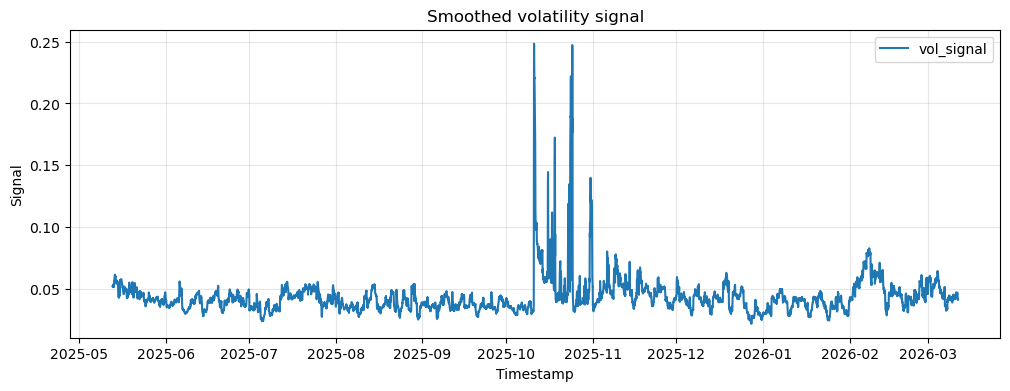

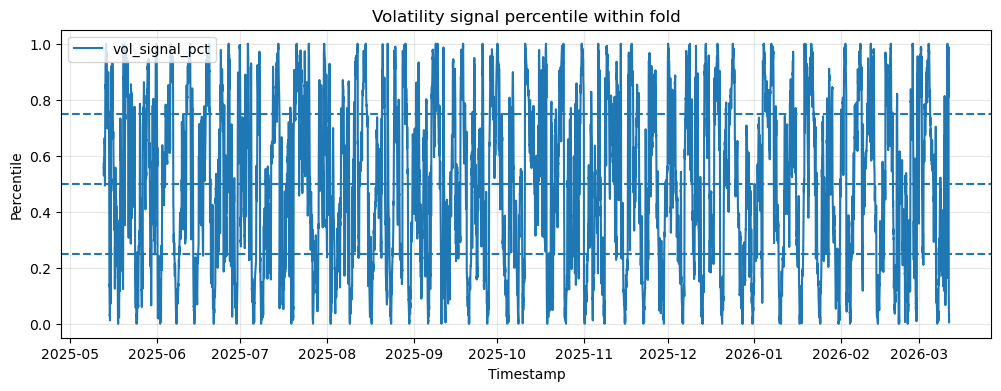

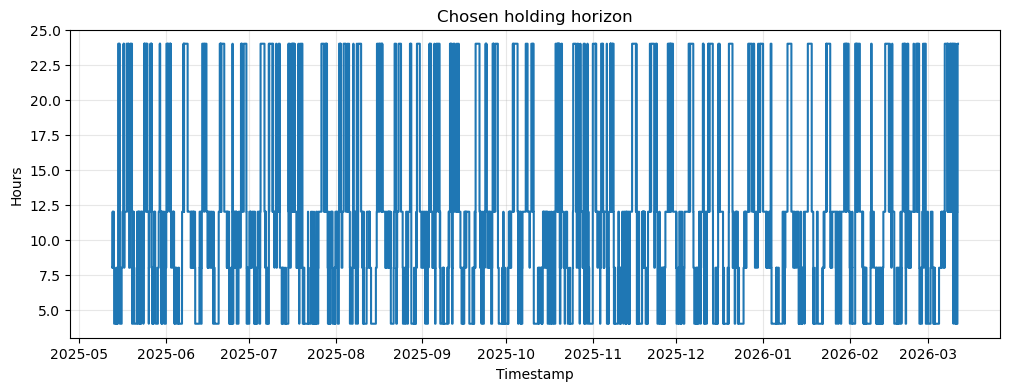

In [20]:
# === Cell 7: adaptive horizon mapping from predicted vol (12h base logic) ===

# -------------------------------------------------
# 1. BUILD TIMESTAMP-LEVEL VOL SIGNALS
# -------------------------------------------------
vol_ts = (
    vol_preds_oos.groupby(["timestamp", "fold"], as_index=False)
    .agg(
        pred_future_rv_24h_mkt=("pred_future_rv_24h", "mean"),
        pred_future_rv_24h_median=("pred_future_rv_24h", "median"),
        pred_future_rv_24h_q75=("pred_future_rv_24h", lambda x: np.nanquantile(x, 0.75)),
        q25=("q25", "first"),
        q50=("q50", "first"),
        q75=("q75", "first"),
    )
    .sort_values(["fold", "timestamp"])
    .reset_index(drop=True)
)

# BTC as auxiliary anchor
if btc_symbol is not None:
    btc_vol_ts = (
        vol_preds_oos.loc[
            vol_preds_oos["symbol"] == btc_symbol,
            ["timestamp", "fold", "pred_future_rv_24h"]
        ]
        .rename(columns={"pred_future_rv_24h": "pred_future_rv_24h_btc"})
        .copy()
    )
    vol_ts = vol_ts.merge(btc_vol_ts, on=["timestamp", "fold"], how="left")
else:
    vol_ts["pred_future_rv_24h_btc"] = np.nan

# -------------------------------------------------
# 2. MAIN VOL SIGNAL
# -------------------------------------------------
# Базовый сигнал = рынок
# BTC добавляем как доп. стресс-якорь, но не даем ему доминировать
vol_ts["pred_future_rv_24h_btc"] = vol_ts["pred_future_rv_24h_btc"].fillna(vol_ts["pred_future_rv_24h_mkt"])

vol_ts["vol_signal_raw"] = (
    0.70 * vol_ts["pred_future_rv_24h_mkt"] +
    0.30 * vol_ts["pred_future_rv_24h_btc"]
)

# Небольшое сглаживание, чтобы selector не дергался на каждом баре
vol_ts["vol_signal"] = (
    vol_ts.groupby("fold")["vol_signal_raw"]
    .transform(lambda x: x.ewm(span=8, adjust=False).mean())
)

# -------------------------------------------------
# 3. FOLD-WISE PERCENTILE OF SIGNAL
# -------------------------------------------------
# Смотрим не на "сырую" величину, а на положение сигнала внутри конкретного fold
vol_ts["vol_signal_pct"] = (
    vol_ts.groupby("fold")["vol_signal"]
    .rank(pct=True)
)

# -------------------------------------------------
# 4. HORIZON MAPPING
# -------------------------------------------------
# Логика:
# - нижний квартиль -> 24h (затухание, низкая вола)
# - между 25% и 50% -> 12h (база)
# - между 50% и 75% -> 8h (умеренная/выше средней вола)
# - верхний квартиль -> 4h (высокая вола)
vol_ts["chosen_horizon_hours"] = np.select(
    [
        vol_ts["vol_signal_pct"] <= 0.20,
        vol_ts["vol_signal_pct"] > 0.75,
        vol_ts["vol_signal_pct"] > 0.55,
    ],
    [24, 4, 8],
    default=12
).astype(int)

vol_ts["chosen_horizon_bars"] = (
    vol_ts["chosen_horizon_hours"] * 60 // BAR_MINUTES
).astype(int)

vol_ts["vol_regime_label"] = np.select(
    [
        vol_ts["chosen_horizon_hours"] == 24,
        vol_ts["chosen_horizon_hours"] == 12,
        vol_ts["chosen_horizon_hours"] == 8,
        vol_ts["chosen_horizon_hours"] == 4,
    ],
    ["decay_low_vol", "base_normal_vol", "moderate_high_vol", "high_vol"],
    default="base_normal_vol"
)

# -------------------------------------------------
# 5. DIAGNOSTICS
# -------------------------------------------------
display(
    vol_ts[
        [
            "timestamp",
            "fold",
            "pred_future_rv_24h_mkt",
            "pred_future_rv_24h_btc",
            "vol_signal_raw",
            "vol_signal",
            "vol_signal_pct",
            "q25",
            "q50",
            "q75",
            "chosen_horizon_hours",
            "chosen_horizon_bars",
            "vol_regime_label",
        ]
    ].head(20)
)

print("Распределение горизонтов:")
display(vol_ts["chosen_horizon_hours"].value_counts(dropna=False).sort_index())

print("Распределение горизонтов по фолдам:")
display(
    vol_ts.pivot_table(
        index="fold",
        columns="chosen_horizon_hours",
        values="timestamp",
        aggfunc="count",
        fill_value=0
    ).head(20)
)

plt.figure(figsize=(12, 4))
plt.plot(vol_ts["timestamp"], vol_ts["vol_signal"], label="vol_signal")
plt.title("Smoothed volatility signal")
plt.xlabel("Timestamp")
plt.ylabel("Signal")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(vol_ts["timestamp"], vol_ts["vol_signal_pct"], label="vol_signal_pct")
plt.axhline(0.25, linestyle="--")
plt.axhline(0.50, linestyle="--")
plt.axhline(0.75, linestyle="--")
plt.title("Volatility signal percentile within fold")
plt.xlabel("Timestamp")
plt.ylabel("Percentile")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.step(vol_ts["timestamp"], vol_ts["chosen_horizon_hours"], where="post")
plt.title("Chosen holding horizon")
plt.xlabel("Timestamp")
plt.ylabel("Hours")
plt.grid(alpha=0.3)
plt.show()

In [21]:
# === Cell 6: OOS vol model (LightGBM) ===

VOL_FEATURES = list(dict.fromkeys(VOL_FEATURES))

vol_test_parts = []
vol_fold_metrics = []

for _, f in folds_df.iterrows():
    fold_id = int(f["fold"])

    train_mask = (
        (panel_ml["timestamp"] >= f["train_start"]) &
        (panel_ml["timestamp"] <  f["train_end"]) &
        (panel_ml["is_trade_allowed"] == 1)
    )
    test_mask = (
        (panel_ml["timestamp"] >= f["test_start"]) &
        (panel_ml["timestamp"] <  f["test_end"]) &
        (panel_ml["is_trade_allowed"] == 1)
    )

    train_df = panel_ml.loc[train_mask].copy()
    test_df  = panel_ml.loc[test_mask].copy()

    train_df = train_df.dropna(subset=VOL_FEATURES + ["future_rv_24h"])
    test_df  = test_df.dropna(subset=VOL_FEATURES + ["future_rv_24h"])

    if len(train_df) == 0 or len(test_df) == 0:
        print(f"Fold {fold_id}: пропуск vol-model, пустой train/test")
        continue

    X_train = train_df.loc[:, VOL_FEATURES].copy()
    y_train = train_df["future_rv_24h"].astype(float)

    X_test = test_df.loc[:, VOL_FEATURES].copy()
    y_test = test_df["future_rv_24h"].astype(float)

    if HAS_LGBM:
        vol_model = LGBMRegressor(**LGBM_PARAMS)
    else:
        vol_model = HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=6,
            max_iter=400,
            random_state=42
        )

    vol_model.fit(X_train, y_train)
    pred_test = np.clip(vol_model.predict(X_test), 0, None)

    q25, q50, q75 = train_df["future_rv_24h"].quantile([0.25, 0.50, 0.75]).values

    test_out = test_df[
        ["timestamp", "symbol", "future_rv_24h", "is_regime_trade_ok"]
    ].copy()
    test_out["pred_future_rv_24h"] = pred_test
    test_out["fold"] = fold_id
    test_out["q25"] = q25
    test_out["q50"] = q50
    test_out["q75"] = q75

    vol_test_parts.append(test_out)

    corr = pd.Series(pred_test).corr(y_test.reset_index(drop=True), method="spearman")
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))

    vol_fold_metrics.append({
        "fold": fold_id,
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "test_start": f["test_start"],
        "test_end": f["test_end"],
        "vol_spearman": corr,
        "vol_rmse": rmse,
        "q25": q25,
        "q50": q50,
        "q75": q75,
        "n_features": len(VOL_FEATURES),
    })

    print(
        f"Fold {fold_id}: "
        f"vol_spearman={corr:.4f} "
        f"vol_rmse={rmse:.6f} "
        f"n_features={len(VOL_FEATURES)}"
    )

vol_preds_oos = (
    pd.concat(vol_test_parts, ignore_index=True)
    .sort_values(["timestamp", "symbol"])
    .reset_index(drop=True)
)

vol_fold_metrics_df = pd.DataFrame(vol_fold_metrics)

display(vol_fold_metrics_df)
display(vol_preds_oos.head())

Fold 1: vol_spearman=0.7994 vol_rmse=0.022379 n_features=54
Fold 2: vol_spearman=0.8312 vol_rmse=0.018734 n_features=54
Fold 3: vol_spearman=0.7532 vol_rmse=0.016579 n_features=54
Fold 4: vol_spearman=0.7432 vol_rmse=0.019517 n_features=54
Fold 5: vol_spearman=0.8358 vol_rmse=0.015886 n_features=54
Fold 6: vol_spearman=0.5521 vol_rmse=0.032744 n_features=54
Fold 7: vol_spearman=0.7745 vol_rmse=0.021774 n_features=54
Fold 8: vol_spearman=0.7718 vol_rmse=0.014133 n_features=54
Fold 9: vol_spearman=0.6839 vol_rmse=0.022390 n_features=54
Fold 10: vol_spearman=0.7315 vol_rmse=0.021918 n_features=54
Fold 11: vol_spearman=0.7162 vol_rmse=0.021336 n_features=54
Fold 12: vol_spearman=0.6998 vol_rmse=0.016824 n_features=54
Fold 13: vol_spearman=0.7492 vol_rmse=0.018216 n_features=54
Fold 14: vol_spearman=0.7162 vol_rmse=0.015447 n_features=54
Fold 15: vol_spearman=0.4252 vol_rmse=0.020088 n_features=54
Fold 16: vol_spearman=0.7529 vol_rmse=0.028923 n_features=54
Fold 17: vol_spearman=0.6968 vol_

,fold,train_rows,test_rows,test_start,test_end,vol_spearman,vol_rmse,q25,q50,q75,n_features
0,1,198842,46368,2025-05-13 00:00:00+00:00,2025-05-20 00:00:00+00:00,0.799432,0.022379,0.034874,0.046607,0.063198,54
1,2,231202,46368,2025-05-20 00:00:00+00:00,2025-05-27 00:00:00+00:00,0.831238,0.018734,0.035784,0.047644,0.064107,54
2,3,231840,46368,2025-05-27 00:00:00+00:00,2025-06-03 00:00:00+00:00,0.753193,0.016579,0.037163,0.049264,0.065599,54
3,4,231840,46368,2025-06-03 00:00:00+00:00,2025-06-10 00:00:00+00:00,0.743176,0.019517,0.036239,0.048383,0.064297,54
4,5,231840,46368,2025-06-10 00:00:00+00:00,2025-06-17 00:00:00+00:00,0.835787,0.015886,0.035320,0.048143,0.063958,54
5,6,231840,46368,2025-06-17 00:00:00+00:00,2025-06-24 00:00:00+00:00,0.552143,0.032744,0.033796,0.045724,0.060838,54
6,7,231840,46368,2025-06-24 00:00:00+00:00,2025-07-01 00:00:00+00:00,0.774529,0.021774,0.033195,0.044956,0.060432,54
7,8,231840,46368,2025-07-01 00:00:00+00:00,2025-07-08 00:00:00+00:00,0.771846,0.014133,0.031346,0.042925,0.057851,54
8,9,231840,46368,2025-07-08 00:00:00+00:00,2025-07-15 00:00:00+00:00,0.683920,0.022390,0.029351,0.039779,0.055126,54
9,10,231840,46368,2025-07-15 00:00:00+00:00,2025-07-22 00:00:00+00:00,0.731460,0.021918,0.031060,0.042010,0.057651,54


,timestamp,symbol,future_rv_24h,is_regime_trade_ok,pred_future_rv_24h,fold,q25,q50,q75
0,2025-05-13 00:00:00+00:00,AAVEUSDT,0.055873,0,0.050731,1,0.034874,0.046607,0.063198
1,2025-05-13 00:00:00+00:00,ADAUSDT,0.048467,0,0.053044,1,0.034874,0.046607,0.063198
2,2025-05-13 00:00:00+00:00,AEROUSDT,0.062346,0,0.064135,1,0.034874,0.046607,0.063198
3,2025-05-13 00:00:00+00:00,ALGOUSDT,0.057977,0,0.063782,1,0.034874,0.046607,0.063198
4,2025-05-13 00:00:00+00:00,APEXUSDT,0.082610,0,0.088683,1,0.034874,0.046607,0.063198


,timestamp,fold,pred_future_rv_24h_mkt,pred_future_rv_24h_btc,vol_signal_raw,vol_signal,vol_signal_pct,q25,q50,q75,chosen_horizon_hours,chosen_horizon_bars,vol_regime_label
0,2025-05-13 00:00:00+00:00,1,0.065988,0.019177,0.051945,0.051945,0.572917,0.034874,0.046607,0.063198,8,32,moderate_high_vol
1,2025-05-13 00:15:00+00:00,1,0.065696,0.019310,0.051780,0.051908,0.566964,0.034874,0.046607,0.063198,8,32,moderate_high_vol
2,2025-05-13 00:30:00+00:00,1,0.065487,0.019306,0.051633,0.051847,0.559524,0.034874,0.046607,0.063198,8,32,moderate_high_vol
3,2025-05-13 00:45:00+00:00,1,0.065150,0.019093,0.051333,0.051733,0.543155,0.034874,0.046607,0.063198,12,48,base_normal_vol
4,2025-05-13 01:00:00+00:00,1,0.065665,0.019383,0.051780,0.051743,0.544643,0.034874,0.046607,0.063198,12,48,base_normal_vol
5,2025-05-13 01:15:00+00:00,1,0.065312,0.018916,0.051393,0.051665,0.535714,0.034874,0.046607,0.063198,12,48,base_normal_vol
6,2025-05-13 01:30:00+00:00,1,0.065512,0.019061,0.051577,0.051646,0.532738,0.034874,0.046607,0.063198,12,48,base_normal_vol
7,2025-05-13 01:45:00+00:00,1,0.065148,0.019581,0.051478,0.051608,0.529762,0.034874,0.046607,0.063198,12,48,base_normal_vol
8,2025-05-13 02:00:00+00:00,1,0.065846,0.019719,0.052008,0.051697,0.538690,0.034874,0.046607,0.063198,12,48,base_normal_vol
9,2025-05-13 02:15:00+00:00,1,0.065961,0.019611,0.052056,0.051777,0.549107,0.034874,0.046607,0.063198,12,48,base_normal_vol


Распределение горизонтов:


chosen_horizon_hours
4      7269
8      5840
12    10167
24     5797
Name: count, dtype: int64

Распределение горизонтов по фолдам:


chosen_horizon_hours,4,8,12,24
fold,,,,
1,168,135,235,134
2,168,135,235,134
3,168,135,235,134
4,168,135,235,134
5,168,135,235,134
6,168,135,235,134
7,168,135,235,134
8,168,135,235,134
9,168,135,235,134


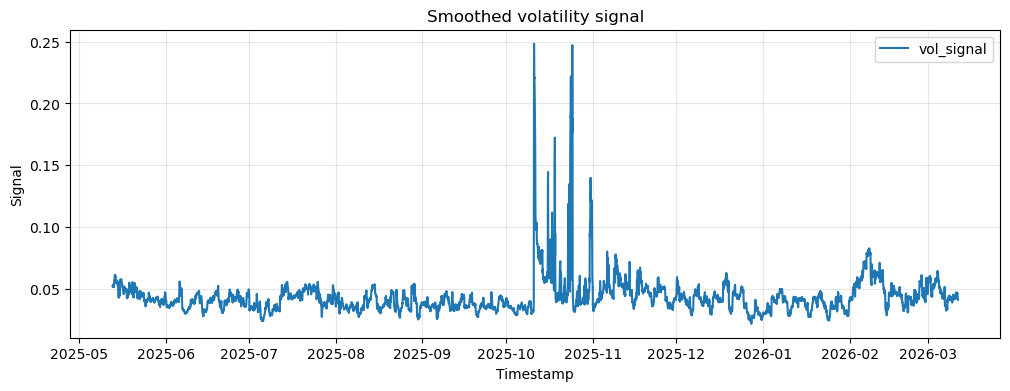

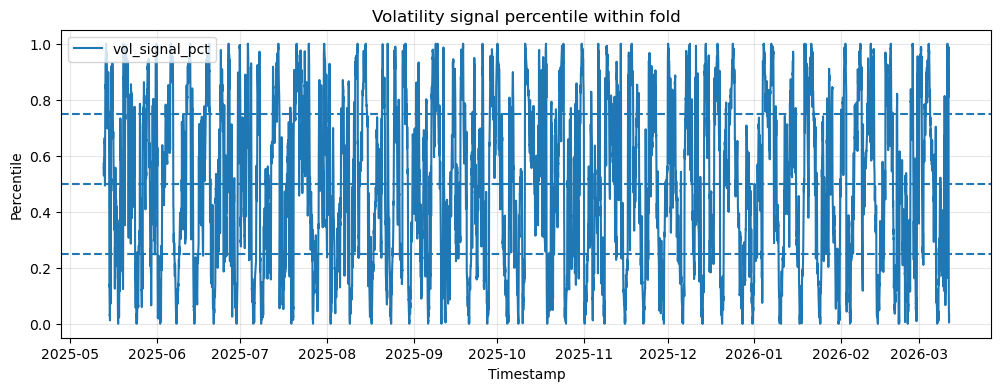

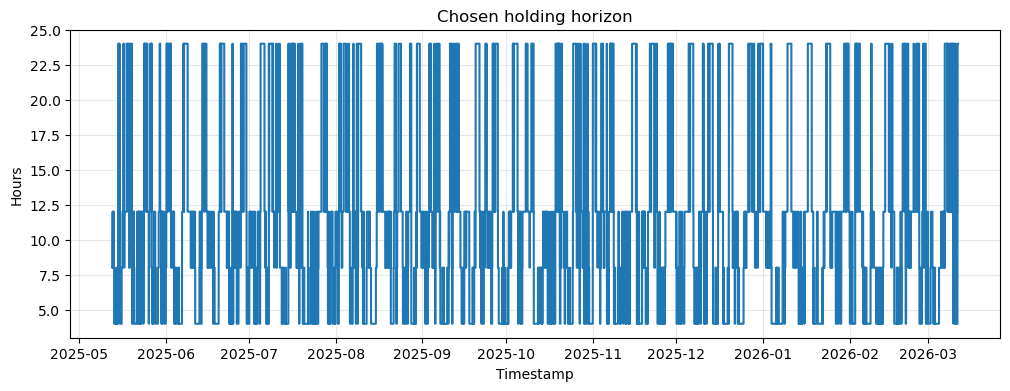

In [24]:
# === Cell 7: adaptive horizon mapping from predicted vol (12h base logic) ===

# -------------------------------------------------
# 1. BUILD TIMESTAMP-LEVEL VOL SIGNALS
# -------------------------------------------------
vol_ts = (
    vol_preds_oos.groupby(["timestamp", "fold"], as_index=False)
    .agg(
        pred_future_rv_24h_mkt=("pred_future_rv_24h", "mean"),
        pred_future_rv_24h_median=("pred_future_rv_24h", "median"),
        pred_future_rv_24h_q75=("pred_future_rv_24h", lambda x: np.nanquantile(x, 0.75)),
        q25=("q25", "first"),
        q50=("q50", "first"),
        q75=("q75", "first"),
    )
    .sort_values(["fold", "timestamp"])
    .reset_index(drop=True)
)

# BTC as auxiliary anchor
if btc_symbol is not None:
    btc_vol_ts = (
        vol_preds_oos.loc[
            vol_preds_oos["symbol"] == btc_symbol,
            ["timestamp", "fold", "pred_future_rv_24h"]
        ]
        .rename(columns={"pred_future_rv_24h": "pred_future_rv_24h_btc"})
        .copy()
    )
    vol_ts = vol_ts.merge(btc_vol_ts, on=["timestamp", "fold"], how="left")
else:
    vol_ts["pred_future_rv_24h_btc"] = np.nan

# -------------------------------------------------
# 2. MAIN VOL SIGNAL
# -------------------------------------------------
# Базовый сигнал = рынок
# BTC добавляем как доп. стресс-якорь, но не даем ему доминировать
vol_ts["pred_future_rv_24h_btc"] = vol_ts["pred_future_rv_24h_btc"].fillna(vol_ts["pred_future_rv_24h_mkt"])

vol_ts["vol_signal_raw"] = (
    0.70 * vol_ts["pred_future_rv_24h_mkt"] +
    0.30 * vol_ts["pred_future_rv_24h_btc"]
)

# Небольшое сглаживание, чтобы selector не дергался на каждом баре
vol_ts["vol_signal"] = (
    vol_ts.groupby("fold")["vol_signal_raw"]
    .transform(lambda x: x.ewm(span=8, adjust=False).mean())
)

# -------------------------------------------------
# 3. FOLD-WISE PERCENTILE OF SIGNAL
# -------------------------------------------------
# Смотрим не на "сырую" величину, а на положение сигнала внутри конкретного fold
vol_ts["vol_signal_pct"] = (
    vol_ts.groupby("fold")["vol_signal"]
    .rank(pct=True)
)

# -------------------------------------------------
# 4. HORIZON MAPPING
# -------------------------------------------------
# Логика:
# - нижний квартиль -> 24h (затухание, низкая вола)
# - между 25% и 50% -> 12h (база)
# - между 50% и 75% -> 8h (умеренная/выше средней вола)
# - верхний квартиль -> 4h (высокая вола)
vol_ts["chosen_horizon_hours"] = np.select(
    [
        vol_ts["vol_signal_pct"] <= 0.20,
        vol_ts["vol_signal_pct"] > 0.75,
        vol_ts["vol_signal_pct"] > 0.55,
    ],
    [24, 4, 8],
    default=12
).astype(int)

vol_ts["chosen_horizon_bars"] = (
    vol_ts["chosen_horizon_hours"] * 60 // BAR_MINUTES
).astype(int)

vol_ts["vol_regime_label"] = np.select(
    [
        vol_ts["chosen_horizon_hours"] == 24,
        vol_ts["chosen_horizon_hours"] == 12,
        vol_ts["chosen_horizon_hours"] == 8,
        vol_ts["chosen_horizon_hours"] == 4,
    ],
    ["decay_low_vol", "base_normal_vol", "moderate_high_vol", "high_vol"],
    default="base_normal_vol"
)

# -------------------------------------------------
# 5. DIAGNOSTICS
# -------------------------------------------------
display(
    vol_ts[
        [
            "timestamp",
            "fold",
            "pred_future_rv_24h_mkt",
            "pred_future_rv_24h_btc",
            "vol_signal_raw",
            "vol_signal",
            "vol_signal_pct",
            "q25",
            "q50",
            "q75",
            "chosen_horizon_hours",
            "chosen_horizon_bars",
            "vol_regime_label",
        ]
    ].head(20)
)

print("Распределение горизонтов:")
display(vol_ts["chosen_horizon_hours"].value_counts(dropna=False).sort_index())

print("Распределение горизонтов по фолдам:")
display(
    vol_ts.pivot_table(
        index="fold",
        columns="chosen_horizon_hours",
        values="timestamp",
        aggfunc="count",
        fill_value=0
    ).head(20)
)

plt.figure(figsize=(12, 4))
plt.plot(vol_ts["timestamp"], vol_ts["vol_signal"], label="vol_signal")
plt.title("Smoothed volatility signal")
plt.xlabel("Timestamp")
plt.ylabel("Signal")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(vol_ts["timestamp"], vol_ts["vol_signal_pct"], label="vol_signal_pct")
plt.axhline(0.25, linestyle="--")
plt.axhline(0.50, linestyle="--")
plt.axhline(0.75, linestyle="--")
plt.title("Volatility signal percentile within fold")
plt.xlabel("Timestamp")
plt.ylabel("Percentile")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.step(vol_ts["timestamp"], vol_ts["chosen_horizon_hours"], where="post")
plt.title("Chosen holding horizon")
plt.xlabel("Timestamp")
plt.ylabel("Hours")
plt.grid(alpha=0.3)
plt.show()

In [26]:
# === Cell 8: CatBoost OOS for all horizons + selected horizon score ===

all_test_preds = []
rank_fold_metrics = []
feature_importance_rows = []

for _, f in folds_df.iterrows():
    fold_id = int(f["fold"])

    train_mask = (
        (panel_ml["timestamp"] >= f["train_start"]) &
        (panel_ml["timestamp"] <  f["train_end"]) &
        (panel_ml["is_trade_allowed"] == 1)
    )
    test_mask = (
        (panel_ml["timestamp"] >= f["test_start"]) &
        (panel_ml["timestamp"] <  f["test_end"]) &
        (panel_ml["is_trade_allowed"] == 1)
    )

    train_df = panel_ml.loc[train_mask].copy()
    test_df  = panel_ml.loc[test_mask].copy()

    base_train = train_df.dropna(subset=RANK_FEATURES).copy()
    base_test  = test_df.dropna(subset=RANK_FEATURES).copy()

    if len(base_train) == 0 or len(base_test) == 0:
        print(f"Fold {fold_id}: пропуск rank-model, пустой train/test")
        continue

    for h in HORIZON_TO_BARS.keys():
        base_test[f"proba_up_{h}h"] = np.nan

    fi_ref = None

    for h in HORIZON_TO_BARS.keys():
        target_col = f"target_up_{h}h"

        train_h = base_train.dropna(subset=[target_col]).copy()
        test_h = base_test.dropna(subset=[target_col]).copy()

        if len(train_h) == 0 or len(test_h) == 0:
            continue

        X_train = train_h[RANK_FEATURES]
        y_train = train_h[target_col].astype(int)

        X_test = test_h[RANK_FEATURES]

        model = CatBoostClassifier(**CAT_PARAMS)
        model.fit(X_train, y_train)

        base_test.loc[test_h.index, f"proba_up_{h}h"] = model.predict_proba(X_test)[:, 1]

        if h == 4:
            fi_ref = pd.DataFrame({
                "feature": RANK_FEATURES,
                "importance": model.get_feature_importance(),
                "fold": fold_id
            })

    if fi_ref is not None:
        feature_importance_rows.append(fi_ref)

    base_test["fold"] = fold_id
    base_test = base_test.merge(
        vol_ts[
            [
                "timestamp",
                "fold",
                "vol_signal",
                "chosen_horizon_hours",
                "chosen_horizon_bars",
                "vol_regime_label"
            ]
        ],
        on=["timestamp", "fold"],
        how="left"
    )

    base_test["proba_up_selected"] = np.nan
    base_test["future_ret_selected"] = np.nan
    base_test["target_up_selected"] = np.nan

    for h in HORIZON_TO_BARS.keys():
        mask = base_test["chosen_horizon_hours"] == h
        base_test.loc[mask, "proba_up_selected"] = base_test.loc[mask, f"proba_up_{h}h"]
        base_test.loc[mask, "future_ret_selected"] = base_test.loc[mask, f"future_ret_{h}h"]
        base_test.loc[mask, "target_up_selected"] = base_test.loc[mask, f"target_up_{h}h"]

    base_test["pred_up_selected"] = (base_test["proba_up_selected"] >= 0.5).astype(float)

    eval_df = base_test.dropna(subset=["proba_up_selected", "target_up_selected", "future_ret_selected"]).copy()

    auc = np.nan
    ll = np.nan
    acc = np.nan

    if len(eval_df) > 0:
        y_eval = eval_df["target_up_selected"].astype(int)
        p_eval = eval_df["proba_up_selected"].astype(float)

        if y_eval.nunique() > 1:
            auc = roc_auc_score(y_eval, p_eval)
            ll = log_loss(y_eval, p_eval)

        acc = accuracy_score(y_eval, (p_eval >= 0.5).astype(int))

    rank_fold_metrics.append({
        "fold": fold_id,
        "train_rows": len(base_train),
        "test_rows": len(base_test),
        "test_start": f["test_start"],
        "test_end": f["test_end"],
        "auc_selected": auc,
        "logloss_selected": ll,
        "accuracy_selected": acc,
        "h4_share": (base_test["chosen_horizon_hours"] == 4).mean(),
        "h8_share": (base_test["chosen_horizon_hours"] == 8).mean(),
        "h12_share": (base_test["chosen_horizon_hours"] == 12).mean(),
        "h24_share": (base_test["chosen_horizon_hours"] == 24).mean(),
    })

    all_test_preds.append(
        base_test[
            [
                "timestamp",
                "symbol",
                "close",
                "fold",
                "is_regime_trade_ok",
                "vol_signal",
                "chosen_horizon_hours",
                "chosen_horizon_bars",
                "vol_regime_label",
                "future_ret_4h",
                "future_ret_8h",
                "future_ret_12h",
                "future_ret_24h",
                "target_up_4h",
                "target_up_8h",
                "target_up_12h",
                "target_up_24h",
                "proba_up_4h",
                "proba_up_8h",
                "proba_up_12h",
                "proba_up_24h",
                "proba_up_selected",
                "future_ret_selected",
                "target_up_selected",
                "pred_up_selected",
                "liquidity_regime",
                "realized_vol_regime",
                "stress_regime",
            ]
        ].copy()
    )

    print(f"Fold {fold_id}: AUC_selected={auc:.4f} ACC_selected={acc:.4f}")

preds_oos = (
    pd.concat(all_test_preds, ignore_index=True)
    .sort_values(["timestamp", "symbol"])
    .reset_index(drop=True)
)

rank_fold_metrics_df = pd.DataFrame(rank_fold_metrics)

if len(feature_importance_rows) > 0:
    feature_importance_df = pd.concat(feature_importance_rows, ignore_index=True)
else:
    feature_importance_df = pd.DataFrame(columns=["feature", "importance", "fold"])

display(rank_fold_metrics_df)
display(preds_oos.head())

Fold 1: AUC_selected=0.3162 ACC_selected=0.3459
Fold 2: AUC_selected=0.4738 ACC_selected=0.4343
Fold 3: AUC_selected=0.4232 ACC_selected=0.4561
Fold 4: AUC_selected=0.5404 ACC_selected=0.5119
Fold 5: AUC_selected=0.5970 ACC_selected=0.5853
Fold 6: AUC_selected=0.6529 ACC_selected=0.6082
Fold 7: AUC_selected=0.5507 ACC_selected=0.5421
Fold 8: AUC_selected=0.5519 ACC_selected=0.5312
Fold 9: AUC_selected=0.4359 ACC_selected=0.3668
Fold 10: AUC_selected=0.5238 ACC_selected=0.4851
Fold 11: AUC_selected=0.6494 ACC_selected=0.5958
Fold 12: AUC_selected=0.5056 ACC_selected=0.5050
Fold 13: AUC_selected=0.5070 ACC_selected=0.5282
Fold 14: AUC_selected=0.4018 ACC_selected=0.4326
Fold 15: AUC_selected=0.5579 ACC_selected=0.5638
Fold 16: AUC_selected=0.4568 ACC_selected=0.4731
Fold 17: AUC_selected=0.5887 ACC_selected=0.5540
Fold 18: AUC_selected=0.5336 ACC_selected=0.5388
Fold 19: AUC_selected=0.5826 ACC_selected=0.5581
Fold 20: AUC_selected=0.4220 ACC_selected=0.4348
Fold 21: AUC_selected=0.5459 

,fold,train_rows,test_rows,test_start,test_end,auc_selected,logloss_selected,accuracy_selected,h4_share,h8_share,h12_share,h24_share
0,1,198842,46368,2025-05-13 00:00:00+00:00,2025-05-20 00:00:00+00:00,0.316214,0.990371,0.345907,0.250000,0.200893,0.349702,0.199405
1,2,231202,46368,2025-05-20 00:00:00+00:00,2025-05-27 00:00:00+00:00,0.473845,0.844938,0.434265,0.250000,0.200893,0.349702,0.199405
2,3,231840,46368,2025-05-27 00:00:00+00:00,2025-06-03 00:00:00+00:00,0.423234,0.813241,0.456069,0.250000,0.200893,0.349702,0.199405
3,4,231840,46368,2025-06-03 00:00:00+00:00,2025-06-10 00:00:00+00:00,0.540381,0.915647,0.511926,0.250000,0.200893,0.349702,0.199405
4,5,231840,46368,2025-06-10 00:00:00+00:00,2025-06-17 00:00:00+00:00,0.597017,0.719928,0.585339,0.250000,0.200893,0.349702,0.199405
5,6,231840,46368,2025-06-17 00:00:00+00:00,2025-06-24 00:00:00+00:00,0.652942,0.736266,0.608221,0.250000,0.200893,0.349702,0.199405
6,7,231840,46368,2025-06-24 00:00:00+00:00,2025-07-01 00:00:00+00:00,0.550727,0.822008,0.542076,0.250000,0.200893,0.349702,0.199405
7,8,231840,46368,2025-07-01 00:00:00+00:00,2025-07-08 00:00:00+00:00,0.551941,0.864327,0.531164,0.250000,0.200893,0.349702,0.199405
8,9,231840,46368,2025-07-08 00:00:00+00:00,2025-07-15 00:00:00+00:00,0.435933,1.105145,0.366805,0.250000,0.200893,0.349702,0.199405
9,10,231840,46368,2025-07-15 00:00:00+00:00,2025-07-22 00:00:00+00:00,0.523786,0.915929,0.485054,0.250000,0.200893,0.349702,0.199405


,timestamp,symbol,close,fold,is_regime_trade_ok,vol_signal,chosen_horizon_hours,chosen_horizon_bars,vol_regime_label,future_ret_4h,...,proba_up_8h,proba_up_12h,proba_up_24h,proba_up_selected,future_ret_selected,target_up_selected,pred_up_selected,liquidity_regime,realized_vol_regime,stress_regime
0,2025-05-13 00:00:00+00:00,AAVEUSDT,219.6100,1,0,0.051945,8.0,32.0,moderate_high_vol,-0.036975,...,0.241298,0.271719,0.602231,0.241298,-0.017804,0.0,0.0,0,0,3
1,2025-05-13 00:00:00+00:00,ADAUSDT,0.8102,1,0,0.051945,8.0,32.0,moderate_high_vol,-0.041595,...,0.250643,0.288927,0.772283,0.250643,-0.021229,0.0,0.0,2,0,3
2,2025-05-13 00:00:00+00:00,AEROUSDT,0.7161,1,0,0.051945,8.0,32.0,moderate_high_vol,-0.044547,...,0.175591,0.258514,0.843186,0.175591,-0.018154,0.0,0.0,0,1,3
3,2025-05-13 00:00:00+00:00,ALGOUSDT,0.2403,1,0,0.051945,8.0,32.0,moderate_high_vol,-0.056596,...,0.211134,0.298614,0.873512,0.211134,-0.023304,0.0,0.0,1,1,3
4,2025-05-13 00:00:00+00:00,APEXUSDT,0.5979,1,0,0.051945,8.0,32.0,moderate_high_vol,0.011540,...,0.180154,0.453976,0.244663,0.180154,-0.011875,0.0,0.0,2,2,3


In [27]:
# === Cell 9: mark decision timestamps ===

ts_df = preds_oos[["timestamp"]].drop_duplicates().sort_values("timestamp").reset_index(drop=True)
ts_df["bar_id"] = np.arange(len(ts_df))
ts_df["is_decision"] = ts_df["bar_id"] % BASE_REBALANCE_BARS == 0

preds_oos = preds_oos.merge(ts_df, on="timestamp", how="left")

decision_df = preds_oos.loc[preds_oos["is_decision"]].copy()
decision_df = decision_df.dropna(subset=["proba_up_selected", "future_ret_selected", "chosen_horizon_hours"])

print("Всего decision timestamps:", decision_df["timestamp"].nunique())
display(decision_df.head())

Всего decision timestamps: 1818


,timestamp,symbol,close,fold,is_regime_trade_ok,vol_signal,chosen_horizon_hours,chosen_horizon_bars,vol_regime_label,future_ret_4h,...,proba_up_24h,proba_up_selected,future_ret_selected,target_up_selected,pred_up_selected,liquidity_regime,realized_vol_regime,stress_regime,bar_id,is_decision
0,2025-05-13 00:00:00+00:00,AAVEUSDT,219.6100,1,0,0.051945,8.0,32.0,moderate_high_vol,-0.036975,...,0.602231,0.241298,-0.017804,0.0,0.0,0,0,3,0,True
1,2025-05-13 00:00:00+00:00,ADAUSDT,0.8102,1,0,0.051945,8.0,32.0,moderate_high_vol,-0.041595,...,0.772283,0.250643,-0.021229,0.0,0.0,2,0,3,0,True
2,2025-05-13 00:00:00+00:00,AEROUSDT,0.7161,1,0,0.051945,8.0,32.0,moderate_high_vol,-0.044547,...,0.843186,0.175591,-0.018154,0.0,0.0,0,1,3,0,True
3,2025-05-13 00:00:00+00:00,ALGOUSDT,0.2403,1,0,0.051945,8.0,32.0,moderate_high_vol,-0.056596,...,0.873512,0.211134,-0.023304,0.0,0.0,1,1,3,0,True
4,2025-05-13 00:00:00+00:00,APEXUSDT,0.5979,1,0,0.051945,8.0,32.0,moderate_high_vol,0.011540,...,0.244663,0.180154,-0.011875,0.0,0.0,2,2,3,0,True


# === Cell 10: adaptive strategy long top 3 short bottom 3 ===

def build_adaptive_long_short_top_bottom_strategy(
    df,
    top_n=3,
    bottom_n=3,
    fee_rate=0.0003,
    min_names=10
):
    picks = []
    port_rows = []

    timestamps = sorted(df["timestamp"].drop_duplicates())
    grouped = {ts: grp.copy() for ts, grp in df.groupby("timestamp")}

    next_trade_time = timestamps[0] if len(timestamps) > 0 else None
    prev_weights = {}

    for ts in timestamps:
        if next_trade_time is not None and ts < next_trade_time:
            continue

        g = grouped[ts].copy()
        g = g.loc[g["is_regime_trade_ok"] == 1].copy()
        g = g.dropna(subset=["proba_up_selected", "future_ret_selected", "chosen_horizon_hours"])

        if len(g) < max(top_n + bottom_n, min_names):
            continue

        horizon_hours = int(g["chosen_horizon_hours"].mode().iloc[0])
        horizon_bars = int(g["chosen_horizon_bars"].mode().iloc[0])

        g = g.sort_values("proba_up_selected", ascending=False).copy()

        long_leg = g.head(top_n).copy()
        short_leg = g.tail(bottom_n).copy()

        if len(long_leg) == 0 or len(short_leg) == 0:
            continue

        long_leg["side"] = 1
        long_leg["weight"] = 0.5 / len(long_leg)
        long_leg["port_ret_contrib"] = long_leg["weight"] * long_leg["future_ret_selected"]
        long_leg["hold_hours"] = horizon_hours

        short_leg["side"] = -1
        short_leg["weight"] = 0.5 / len(short_leg)
        short_leg["port_ret_contrib"] = short_leg["weight"] * (-short_leg["future_ret_selected"])
        short_leg["hold_hours"] = horizon_hours

        picks.append(long_leg)
        picks.append(short_leg)

        cur_weights = {}
        for _, r in pd.concat([long_leg, short_leg], ignore_index=True).iterrows():
            cur_weights[r["symbol"]] = r["side"] * r["weight"]

        all_syms = set(prev_weights.keys()).union(set(cur_weights.keys()))
        turnover = sum(abs(cur_weights.get(s, 0.0) - prev_weights.get(s, 0.0)) for s in all_syms)

        gross_ret = long_leg["port_ret_contrib"].sum() + short_leg["port_ret_contrib"].sum()
        fee_paid = turnover * fee_rate
        net_ret = gross_ret - fee_paid

        port_rows.append({
            "timestamp": ts,
            "hold_hours": horizon_hours,
            "hold_bars": horizon_bars,
            "gross_ret": gross_ret,
            "turnover": turnover,
            "fee_paid": fee_paid,
            "net_ret": net_ret,
            "n_assets": len(long_leg) + len(short_leg),
            "vol_signal": g["vol_signal"].iloc[0],
        })

        prev_weights = cur_weights
        next_trade_time = ts + pd.Timedelta(hours=horizon_hours)

    if len(picks) == 0:
        return pd.DataFrame(), pd.DataFrame()

    picks_df = pd.concat(picks, ignore_index=True).sort_values(["timestamp", "side", "proba_up_selected"], ascending=[True, False, False]).reset_index(drop=True)
    port = pd.DataFrame(port_rows).sort_values("timestamp").reset_index(drop=True)

    port["equity_gross"] = (1.0 + port["gross_ret"]).cumprod()
    port["equity_net"] = (1.0 + port["net_ret"]).cumprod()

    return picks_df, port

ls_picks, ls_port = build_adaptive_long_short_top_bottom_strategy(
    decision_df,
    top_n=TOP_N,
    bottom_n=BOTTOM_N,
    fee_rate=FEE_RATE,
    min_names=TOP_N + BOTTOM_N
)

display(ls_picks.head())
display(ls_port.head())

In [29]:
# === Cell 11: strategy metrics ===

def calc_strategy_metrics(port_df, strategy_name):
    if len(port_df) == 0:
        return pd.DataFrame([{
            "strategy": strategy_name,
            "n_rebalances": 0
        }])

    gross = port_df["gross_ret"].dropna().copy()
    net = port_df["net_ret"].dropna().copy()

    avg_hold_hours = port_df["hold_hours"].mean()
    periods_per_year = (24 * 365) / avg_hold_hours if avg_hold_hours > 0 else np.nan
    ann_factor = np.sqrt(periods_per_year) if pd.notna(periods_per_year) else np.nan

    gross_total_return = (1.0 + gross).prod() - 1.0
    net_total_return = (1.0 + net).prod() - 1.0

    gross_mean = gross.mean()
    net_mean = net.mean()

    gross_std = gross.std(ddof=1)
    net_std = net.std(ddof=1)

    gross_sharpe = np.nan if gross_std == 0 or pd.isna(gross_std) else gross_mean / gross_std * ann_factor
    net_sharpe = np.nan if net_std == 0 or pd.isna(net_std) else net_mean / net_std * ann_factor

    eq_net = (1.0 + net).cumprod()
    peak = eq_net.cummax()
    dd = eq_net / peak - 1.0
    max_dd_net = dd.min()

    return pd.DataFrame([{
        "strategy": strategy_name,
        "n_rebalances": len(port_df),
        "avg_hold_hours": avg_hold_hours,
        "gross_return": gross_total_return,
        "net_return": net_total_return,
        "gross_mean_ret": gross_mean,
        "net_mean_ret": net_mean,
        "gross_std_ret": gross_std,
        "net_std_ret": net_std,
        "gross_hit_rate": (gross > 0).mean(),
        "net_hit_rate": (net > 0).mean(),
        "gross_sharpe_ann": gross_sharpe,
        "net_sharpe_ann": net_sharpe,
        "avg_turnover": port_df["turnover"].mean(),
        "total_fee_paid": port_df["fee_paid"].sum(),
        "max_drawdown_net": max_dd_net
    }])

strategy_metrics_df = pd.concat([
    calc_strategy_metrics(ls_port, "adaptive_long_top3_short_bottom3"),
], ignore_index=True)

display(strategy_metrics_df)

,strategy,n_rebalances,avg_hold_hours,gross_return,net_return,gross_mean_ret,net_mean_ret,gross_std_ret,net_std_ret,gross_hit_rate,net_hit_rate,gross_sharpe_ann,net_sharpe_ann,avg_turnover,total_fee_paid,max_drawdown_net
0,adaptive_long_top3_short_bottom3,726,9.344353,2.441645,1.422553,0.001866,0.001381,0.017772,0.01777,0.570248,0.560606,3.214371,2.380246,1.614325,0.3516,-0.250454


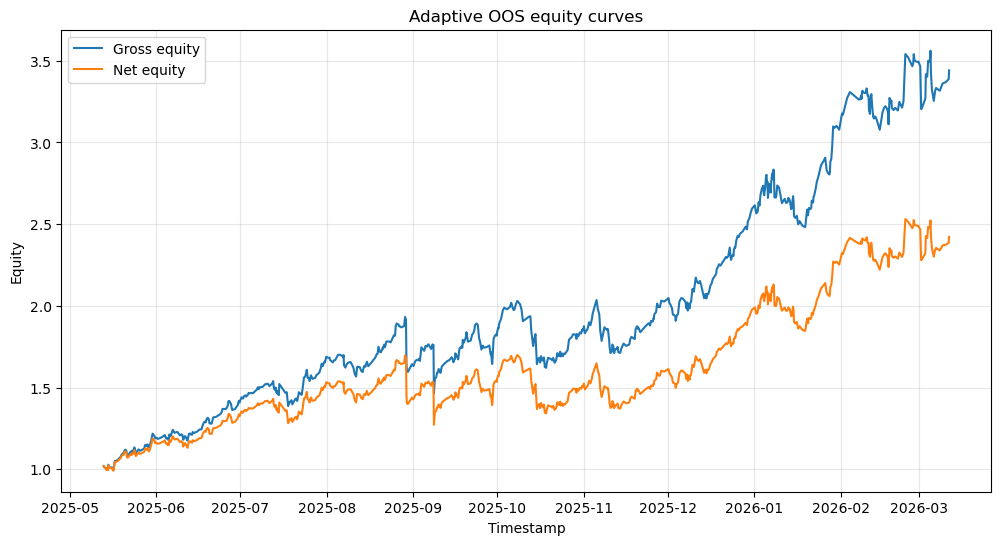

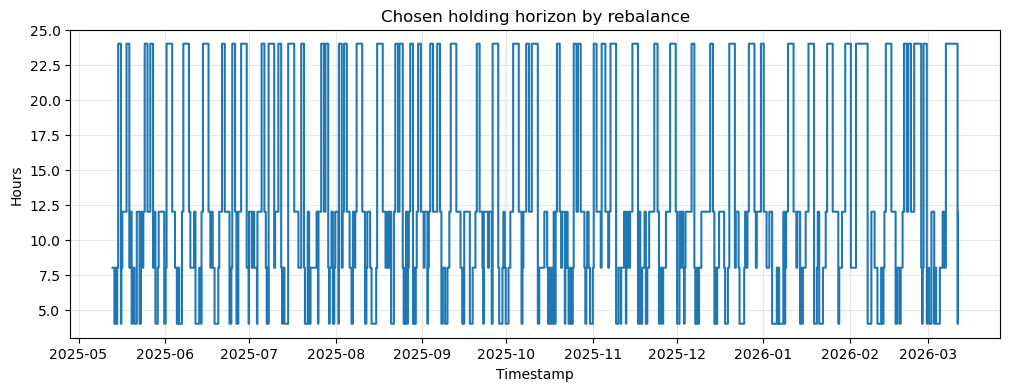

In [30]:
# === Cell 12: plot equity + chosen horizon ===

plt.figure(figsize=(12, 6))
plt.plot(ls_port["timestamp"], ls_port["equity_gross"], label="Gross equity")
plt.plot(ls_port["timestamp"], ls_port["equity_net"], label="Net equity")
plt.title("Adaptive OOS equity curves")
plt.xlabel("Timestamp")
plt.ylabel("Equity")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.step(ls_port["timestamp"], ls_port["hold_hours"], where="post")
plt.title("Chosen holding horizon by rebalance")
plt.xlabel("Timestamp")
plt.ylabel("Hours")
plt.grid(alpha=0.3)
plt.show()

ADAPTIVE LONG TOP 3 + SHORT BOTTOM 3


,timestamp,symbol,side,chosen_horizon_hours,vol_regime_label,proba_up_selected,future_ret_selected,weight,liquidity_regime,realized_vol_regime,stress_regime
0,2025-05-13 04:00:00+00:00,BTCUSDT,1,8.0,moderate_high_vol,0.583187,0.015990,0.166667,1,0,2
1,2025-05-13 04:00:00+00:00,TOSHIUSDT,1,8.0,moderate_high_vol,0.490386,0.099045,0.166667,2,2,2
2,2025-05-13 04:00:00+00:00,FILUSDT,1,8.0,moderate_high_vol,0.468993,0.033164,0.166667,1,1,2
3,2025-05-13 04:00:00+00:00,OPUSDT,-1,8.0,moderate_high_vol,0.272761,0.031008,0.166667,1,1,2
4,2025-05-13 04:00:00+00:00,LAVAUSDT,-1,8.0,moderate_high_vol,0.201754,0.034979,0.166667,0,2,2
5,2025-05-13 04:00:00+00:00,APEXUSDT,-1,8.0,moderate_high_vol,0.171222,-0.031581,0.166667,2,2,2
6,2025-05-13 12:00:00+00:00,TONUSDT,1,8.0,moderate_high_vol,0.464575,0.041029,0.166667,1,0,2
7,2025-05-13 12:00:00+00:00,MNTUSDT,1,8.0,moderate_high_vol,0.440801,0.038814,0.166667,2,0,2
8,2025-05-13 12:00:00+00:00,TRXUSDT,1,8.0,moderate_high_vol,0.424333,0.028009,0.166667,2,0,2
9,2025-05-13 12:00:00+00:00,TOSHIUSDT,-1,8.0,moderate_high_vol,0.215943,0.030981,0.166667,2,2,2


,feature,importance_mean,importance_std
0,btc_rv_24h,18.200149,2.184459
1,market_rv_24h_mean,17.975509,2.062532
2,btc_atr20_pct,10.456157,1.394625
3,hour_cos,8.226797,1.623053
4,dow_sin,6.886438,1.456751
5,hour_utc,5.762827,1.056488
6,hour_sin,5.210378,1.342849
7,dayofweek_utc,5.172468,1.242504
8,dow_cos,4.834694,1.503996
9,rv_1d_mean_7d,0.993397,0.451193


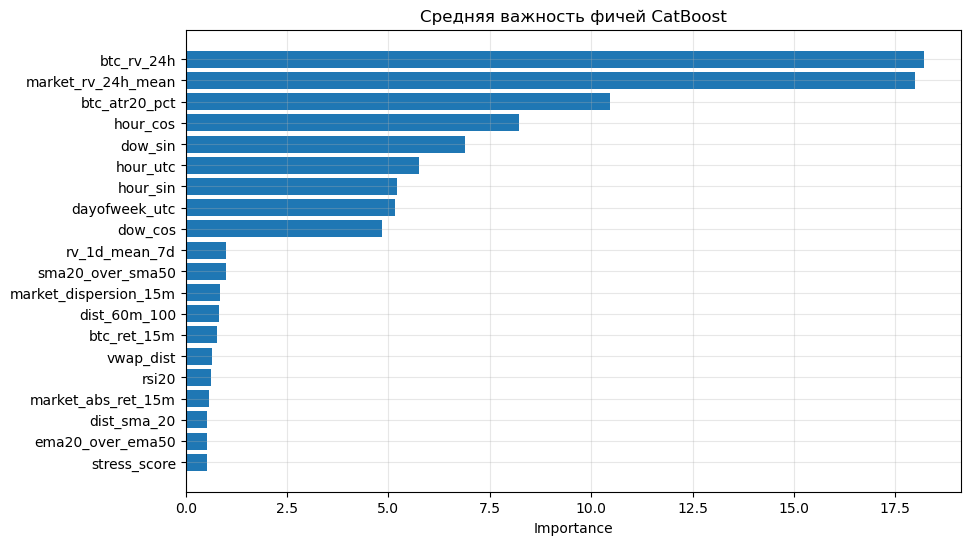

In [31]:
# === Cell 13: inspect picks + feature importance summary ===

print("ADAPTIVE LONG TOP 3 + SHORT BOTTOM 3")
display(
    ls_picks[
        [
            "timestamp",
            "symbol",
            "side",
            "chosen_horizon_hours",
            "vol_regime_label",
            "proba_up_selected",
            "future_ret_selected",
            "weight",
            "liquidity_regime",
            "realized_vol_regime",
            "stress_regime",
        ]
    ]
    .sort_values(["timestamp", "side", "proba_up_selected"], ascending=[True, False, False])
    .head(50)
)

if len(feature_importance_df) > 0:
    fi_summary = (
        feature_importance_df
        .groupby("feature")["importance"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "importance_mean", "std": "importance_std"})
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )

    display(fi_summary.head(20))

    plt.figure(figsize=(10, 6))
    plt.barh(
        fi_summary["feature"].head(20)[::-1],
        fi_summary["importance_mean"].head(20)[::-1]
    )
    plt.title("Средняя важность фичей CatBoost")
    plt.xlabel("Importance")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("feature_importance_df пуст")

,timestamp,chosen_horizon_hours,top_mean_ret,bottom_mean_ret,spread_top_minus_bottom,cum_spread
0,2025-05-13 04:00:00+00:00,8,0.049400,0.011469,0.037931,0.037931
1,2025-05-13 12:00:00+00:00,8,0.035951,0.052847,-0.016896,0.021035
2,2025-05-13 20:00:00+00:00,4,0.000037,0.004560,-0.004523,0.016512
3,2025-05-14 00:00:00+00:00,4,-0.022419,-0.017627,-0.004793,0.011719
4,2025-05-14 04:00:00+00:00,4,0.021421,0.036351,-0.014930,-0.003211


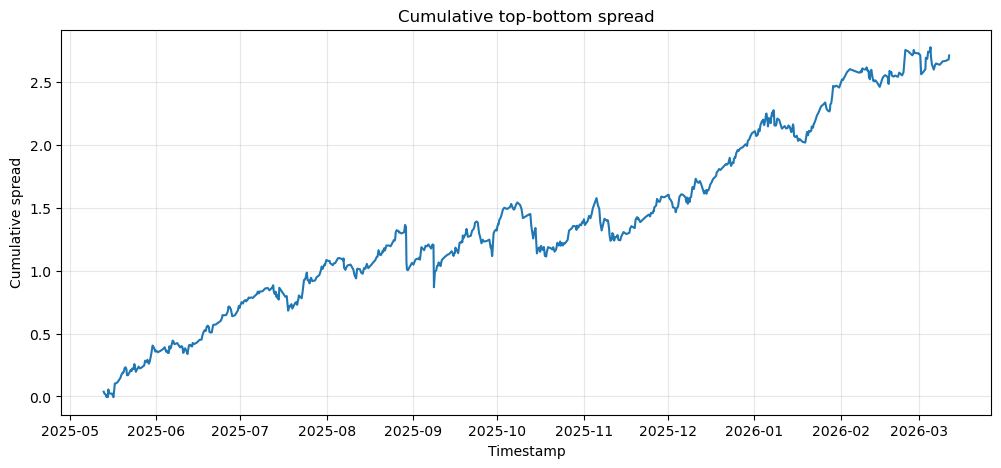

==== Метрики vol-модели по фолдам ====


,fold,train_rows,test_rows,test_start,test_end,vol_spearman,vol_rmse,q25,q50,q75,n_features
0,1,198842,46368,2025-05-13 00:00:00+00:00,2025-05-20 00:00:00+00:00,0.799432,0.022379,0.034874,0.046607,0.063198,54
1,2,231202,46368,2025-05-20 00:00:00+00:00,2025-05-27 00:00:00+00:00,0.831238,0.018734,0.035784,0.047644,0.064107,54
2,3,231840,46368,2025-05-27 00:00:00+00:00,2025-06-03 00:00:00+00:00,0.753193,0.016579,0.037163,0.049264,0.065599,54
3,4,231840,46368,2025-06-03 00:00:00+00:00,2025-06-10 00:00:00+00:00,0.743176,0.019517,0.036239,0.048383,0.064297,54
4,5,231840,46368,2025-06-10 00:00:00+00:00,2025-06-17 00:00:00+00:00,0.835787,0.015886,0.035320,0.048143,0.063958,54
5,6,231840,46368,2025-06-17 00:00:00+00:00,2025-06-24 00:00:00+00:00,0.552143,0.032744,0.033796,0.045724,0.060838,54
6,7,231840,46368,2025-06-24 00:00:00+00:00,2025-07-01 00:00:00+00:00,0.774529,0.021774,0.033195,0.044956,0.060432,54
7,8,231840,46368,2025-07-01 00:00:00+00:00,2025-07-08 00:00:00+00:00,0.771846,0.014133,0.031346,0.042925,0.057851,54
8,9,231840,46368,2025-07-08 00:00:00+00:00,2025-07-15 00:00:00+00:00,0.683920,0.022390,0.029351,0.039779,0.055126,54
9,10,231840,46368,2025-07-15 00:00:00+00:00,2025-07-22 00:00:00+00:00,0.731460,0.021918,0.031060,0.042010,0.057651,54


==== Средние метрики vol-модели ====


,vol_spearman_mean,vol_rmse_mean,n_folds
0,0.67205,0.029656,44


==== Метрики rank-модели по фолдам ====


...

,auc_selected_mean,auc_selected_median,accuracy_selected_mean,logloss_selected_mean,h4_share_mean,h8_share_mean,h12_share_mean,h24_share_mean,n_folds
0,0.51404,0.514437,0.506973,0.816349,0.247784,0.19915,0.347074,0.198,44


==== Метрики стратегии ====


,strategy,n_rebalances,avg_hold_hours,gross_return,net_return,gross_mean_ret,net_mean_ret,gross_std_ret,net_std_ret,gross_hit_rate,net_hit_rate,gross_sharpe_ann,net_sharpe_ann,avg_turnover,total_fee_paid,max_drawdown_net
0,adaptive_long_top3_short_bottom3,726,9.344353,2.441645,1.422553,0.001866,0.001381,0.017772,0.01777,0.570248,0.560606,3.214371,2.380246,1.614325,0.3516,-0.250454


==== Средний top-bottom spread ====


,mean_spread,median_spread,positive_spread_share,n_rebalances
0,0.003732,0.005613,0.570248,726


In [32]:
# === Cell 14: spread check + final summary ===

spread_rows = []

actual_trade_ts = set(ls_port["timestamp"].unique())

for ts, grp in decision_df.loc[decision_df["timestamp"].isin(actual_trade_ts)].groupby("timestamp"):
    g = grp.loc[grp["is_regime_trade_ok"] == 1].copy()
    g = g.sort_values("proba_up_selected", ascending=False)

    if len(g) < TOP_N + BOTTOM_N:
        continue

    top_mean = g.head(TOP_N)["future_ret_selected"].mean()
    bot_mean = g.tail(BOTTOM_N)["future_ret_selected"].mean()

    spread_rows.append({
        "timestamp": ts,
        "chosen_horizon_hours": int(g["chosen_horizon_hours"].mode().iloc[0]),
        "top_mean_ret": top_mean,
        "bottom_mean_ret": bot_mean,
        "spread_top_minus_bottom": top_mean - bot_mean
    })

spread_df = pd.DataFrame(spread_rows).sort_values("timestamp").reset_index(drop=True)

if len(spread_df) > 0:
    spread_df["cum_spread"] = spread_df["spread_top_minus_bottom"].cumsum()

    display(spread_df.head())

    plt.figure(figsize=(12, 5))
    plt.plot(spread_df["timestamp"], spread_df["cum_spread"])
    plt.title("Cumulative top-bottom spread")
    plt.xlabel("Timestamp")
    plt.ylabel("Cumulative spread")
    plt.grid(alpha=0.3)
    plt.show()

print("==== Метрики vol-модели по фолдам ====")
display(vol_fold_metrics_df)

print("==== Средние метрики vol-модели ====")
display(
    pd.DataFrame([{
        "vol_spearman_mean": vol_fold_metrics_df["vol_spearman"].mean(),
        "vol_rmse_mean": vol_fold_metrics_df["vol_rmse"].mean(),
        "n_folds": len(vol_fold_metrics_df)
    }])
)

print("==== Метрики rank-модели по фолдам ====")
display(rank_fold_metrics_df)

print("==== Средние метрики rank-модели ====")
display(
    pd.DataFrame([{
        "auc_selected_mean": rank_fold_metrics_df["auc_selected"].mean(),
        "auc_selected_median": rank_fold_metrics_df["auc_selected"].median(),
        "accuracy_selected_mean": rank_fold_metrics_df["accuracy_selected"].mean(),
        "logloss_selected_mean": rank_fold_metrics_df["logloss_selected"].mean(),
        "h4_share_mean": rank_fold_metrics_df["h4_share"].mean(),
        "h8_share_mean": rank_fold_metrics_df["h8_share"].mean(),
        "h12_share_mean": rank_fold_metrics_df["h12_share"].mean(),
        "h24_share_mean": rank_fold_metrics_df["h24_share"].mean(),
        "n_folds": len(rank_fold_metrics_df)
    }])
)

print("==== Метрики стратегии ====")
display(strategy_metrics_df)

if len(spread_df) > 0:
    print("==== Средний top-bottom spread ====")
    display(
        pd.DataFrame([{
            "mean_spread": spread_df["spread_top_minus_bottom"].mean(),
            "median_spread": spread_df["spread_top_minus_bottom"].median(),
            "positive_spread_share": (spread_df["spread_top_minus_bottom"] > 0).mean(),
            "n_rebalances": len(spread_df)
        }])
    )

==== Smart leverage metrics ====


,strategy,n_rebalances,avg_hold_hours,avg_leverage,gross_return,net_return,gross_mean_ret,net_mean_ret,gross_std_ret,net_std_ret,gross_hit_rate,net_hit_rate,gross_sharpe_ann,net_sharpe_ann,avg_turnover,total_fee_paid,max_drawdown_net
0,adaptive_long_top3_short_bottom3_smart_lev,726,9.344353,3.18595,47.412939,14.998059,0.008156,0.006627,0.072611,0.072474,0.570248,0.560606,3.439305,2.799507,1.614325,1.1106,-0.771939


==== Leverage usage by holding horizon ====


,hold_hours,n_trades,avg_leverage,mean_gross_ret,mean_net_ret
0,4,280,1.5,0.000762,0.000271
1,8,174,1.5,0.001591,0.001106
2,12,188,6.0,0.003178,0.002705
3,24,84,6.0,0.003177,0.002693


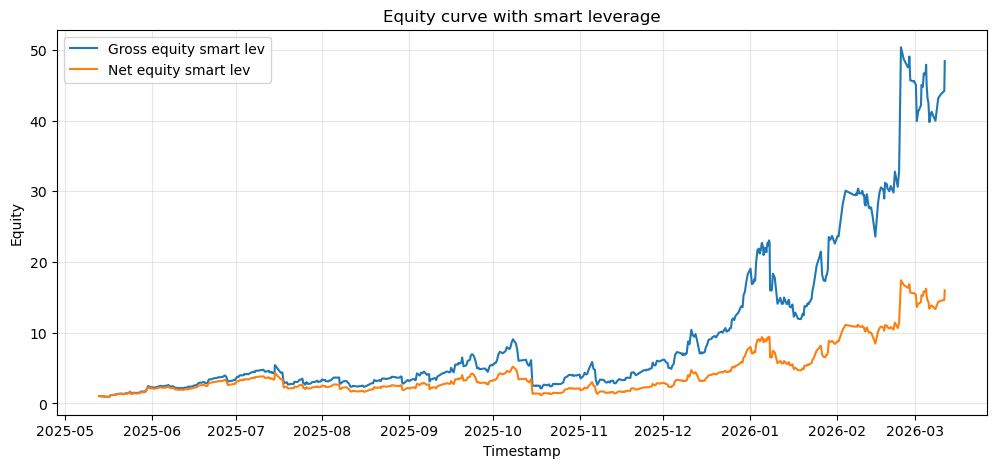

In [35]:
# === smart leverage by chosen holding horizon ===

LEVERAGE_MAP = {
    4: 1.5,
    8: 1.5,
    12: 6,
    24: 6,
}

df = ls_port.copy()

# назначаем плечо по горизонту удержания
df["leverage"] = df["hold_hours"].map(LEVERAGE_MAP).astype(float)

# масштабируем доходности и комиссию
df["gross_ret_smart_lev"] = df["gross_ret"] * df["leverage"]
df["net_ret_smart_lev"] = df["net_ret"] * df["leverage"]
df["fee_paid_smart_lev"] = df["fee_paid"] * df["leverage"]

# equity
df["equity_gross_smart_lev"] = (1 + df["gross_ret_smart_lev"]).cumprod()
df["equity_net_smart_lev"] = (1 + df["net_ret_smart_lev"]).cumprod()

# drawdown
peak = df["equity_net_smart_lev"].cummax()
dd = df["equity_net_smart_lev"] / peak - 1.0

# annualization через средний hold
avg_hold_hours = df["hold_hours"].mean()
periods_per_year = (24 * 365) / avg_hold_hours
ann_factor = np.sqrt(periods_per_year)

gross_std = df["gross_ret_smart_lev"].std(ddof=1)
net_std = df["net_ret_smart_lev"].std(ddof=1)

smart_lev_metrics = pd.DataFrame([{
    "strategy": "adaptive_long_top3_short_bottom3_smart_lev",
    "n_rebalances": len(df),
    "avg_hold_hours": avg_hold_hours,
    "avg_leverage": df["leverage"].mean(),
    "gross_return": df["equity_gross_smart_lev"].iloc[-1] - 1,
    "net_return": df["equity_net_smart_lev"].iloc[-1] - 1,
    "gross_mean_ret": df["gross_ret_smart_lev"].mean(),
    "net_mean_ret": df["net_ret_smart_lev"].mean(),
    "gross_std_ret": gross_std,
    "net_std_ret": net_std,
    "gross_hit_rate": (df["gross_ret_smart_lev"] > 0).mean(),
    "net_hit_rate": (df["net_ret_smart_lev"] > 0).mean(),
    "gross_sharpe_ann": np.nan if gross_std == 0 or pd.isna(gross_std) else df["gross_ret_smart_lev"].mean() / gross_std * ann_factor,
    "net_sharpe_ann": np.nan if net_std == 0 or pd.isna(net_std) else df["net_ret_smart_lev"].mean() / net_std * ann_factor,
    "avg_turnover": df["turnover"].mean(),
    "total_fee_paid": df["fee_paid_smart_lev"].sum(),
    "max_drawdown_net": dd.min(),
}])

print("==== Smart leverage metrics ====")
display(smart_lev_metrics)

print("==== Leverage usage by holding horizon ====")
display(
    df.groupby("hold_hours").agg(
        n_trades=("hold_hours", "size"),
        avg_leverage=("leverage", "mean"),
        mean_gross_ret=("gross_ret", "mean"),
        mean_net_ret=("net_ret", "mean"),
    ).reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["equity_gross_smart_lev"], label="Gross equity smart lev")
plt.plot(df["timestamp"], df["equity_net_smart_lev"], label="Net equity smart lev")
plt.title("Equity curve with smart leverage")
plt.xlabel("Timestamp")
plt.ylabel("Equity")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Всего проверено карт плеч: 1295
Прошли фильтр net_return > 3.5: 952

==== TOP 20 по net_sharpe_ann при net_return > 3.5 ====


,lev_4h,lev_8h,lev_12h,lev_24h,avg_leverage,gross_return,net_return,gross_mean_ret,net_mean_ret,gross_std_ret,net_std_ret,gross_hit_rate,net_hit_rate,gross_sharpe_ann,net_sharpe_ann,avg_turnover,total_fee_paid,max_drawdown_net,n_rebalances
0,1.5,2.5,8.0,8.0,4.174931,52.049371,11.285381,0.010919,0.008916,0.097364,0.097180,0.570248,0.560606,3.433617,2.809048,1.614325,1.4542,-0.917915,726
1,1.5,2.5,7.0,7.0,3.800275,58.102216,14.714619,0.009728,0.007904,0.086318,0.086166,0.570248,0.560606,3.450684,2.808458,1.614325,1.3246,-0.858450,726
2,1.5,3.0,8.0,8.0,4.294766,51.974898,10.755793,0.011109,0.009048,0.098839,0.098663,0.570248,0.560606,3.441439,2.807949,1.614325,1.4964,-0.925313,726
3,1.5,2.0,6.5,6.5,3.493113,54.461762,15.447774,0.008942,0.007265,0.079381,0.079237,0.570248,0.560606,3.449124,2.807333,1.614325,1.2176,-0.818110,726
4,1.5,2.0,7.0,7.0,3.680441,56.235239,14.877434,0.009538,0.007771,0.084937,0.084777,0.570248,0.560606,3.438069,2.806625,1.614325,1.2824,-0.851508,726
5,1.5,2.0,6.0,6.0,3.305785,50.430988,15.292099,0.008347,0.006759,0.073865,0.073737,0.570248,0.560606,3.459944,2.806606,1.614325,1.1528,-0.782222,726
6,2.0,2.5,8.0,8.0,4.367769,54.914786,11.087891,0.011066,0.008968,0.098026,0.097852,0.570248,0.560606,3.456353,2.806075,1.614325,1.5230,-0.916970,726
7,1.5,2.5,6.5,6.5,3.612948,56.270889,15.279111,0.009133,0.007398,0.080858,0.080722,0.570248,0.560606,3.458292,2.805931,1.614325,1.2598,-0.826614,726
8,2.0,3.0,8.0,8.0,4.487603,54.836290,10.566817,0.011256,0.009100,0.099490,0.099325,0.570248,0.560606,3.464137,2.805313,1.614325,1.5652,-0.924454,726
9,1.5,2.0,5.5,5.5,3.118457,44.890752,14.519145,0.007752,0.006253,0.068399,0.068287,0.570248,0.560606,3.469955,2.803696,1.614325,1.0880,-0.743770,726



==== Лучшая карта плеч ====
{4: 1, 8: 2, 12: 8, 24: 8}


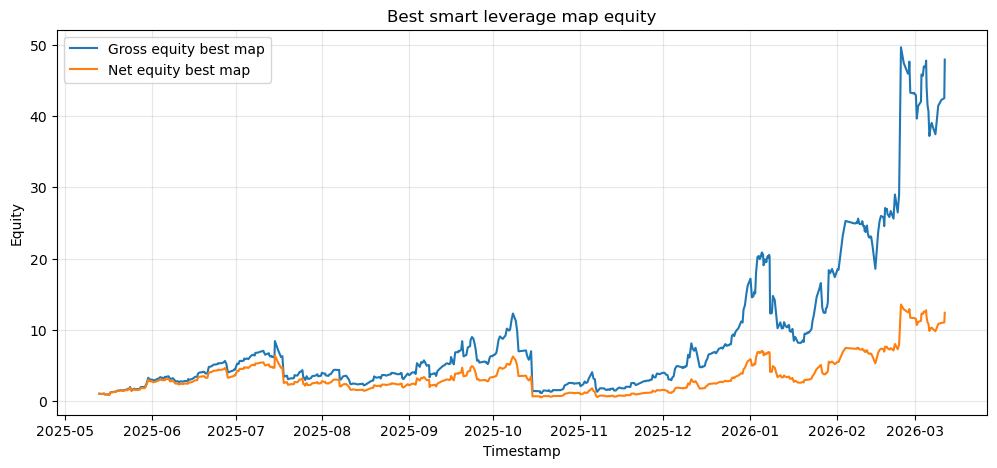

In [34]:
# === grid search: smart leverage map by Sharpe with net_return > 3.5 ===

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# База: текущая таблица стратегии
df_base = ls_port.copy()

# Сетка плеч
LEV_4_LIST = [1.5, 2, 2.5, 3]
LEV_8_LIST = [2, 2.5, 3, 3.5, 4, 4.5, 5]
LEV_12_LIST = [4, 5, 5.5, 6, 6.5, 7, 8]
LEV_24_LIST = [5, 5.5, 6, 6.5, 7, 8, 8.5, 10, 12, 15]

results = []

def evaluate_leverage_map(df, lev_map):
    tmp = df.copy()

    tmp["leverage"] = tmp["hold_hours"].map(lev_map).astype(float)

    # если вдруг появились часы вне карты
    if tmp["leverage"].isna().any():
        return None

    tmp["gross_ret_lev"] = tmp["gross_ret"] * tmp["leverage"]
    tmp["net_ret_lev"] = tmp["net_ret"] * tmp["leverage"]
    tmp["fee_paid_lev"] = tmp["fee_paid"] * tmp["leverage"]

    tmp["equity_gross_lev"] = (1 + tmp["gross_ret_lev"]).cumprod()
    tmp["equity_net_lev"] = (1 + tmp["net_ret_lev"]).cumprod()

    peak = tmp["equity_net_lev"].cummax()
    dd = tmp["equity_net_lev"] / peak - 1.0

    avg_hold_hours = tmp["hold_hours"].mean()
    periods_per_year = (24 * 365) / avg_hold_hours
    ann_factor = np.sqrt(periods_per_year)

    gross_std = tmp["gross_ret_lev"].std(ddof=1)
    net_std = tmp["net_ret_lev"].std(ddof=1)

    gross_sharpe = np.nan
    net_sharpe = np.nan

    if pd.notna(gross_std) and gross_std != 0:
        gross_sharpe = tmp["gross_ret_lev"].mean() / gross_std * ann_factor

    if pd.notna(net_std) and net_std != 0:
        net_sharpe = tmp["net_ret_lev"].mean() / net_std * ann_factor

    return {
        "lev_4h": lev_map[4],
        "lev_8h": lev_map[8],
        "lev_12h": lev_map[12],
        "lev_24h": lev_map[24],
        "avg_leverage": tmp["leverage"].mean(),
        "gross_return": tmp["equity_gross_lev"].iloc[-1] - 1,
        "net_return": tmp["equity_net_lev"].iloc[-1] - 1,
        "gross_mean_ret": tmp["gross_ret_lev"].mean(),
        "net_mean_ret": tmp["net_ret_lev"].mean(),
        "gross_std_ret": gross_std,
        "net_std_ret": net_std,
        "gross_hit_rate": (tmp["gross_ret_lev"] > 0).mean(),
        "net_hit_rate": (tmp["net_ret_lev"] > 0).mean(),
        "gross_sharpe_ann": gross_sharpe,
        "net_sharpe_ann": net_sharpe,
        "avg_turnover": tmp["turnover"].mean(),
        "total_fee_paid": tmp["fee_paid_lev"].sum(),
        "max_drawdown_net": dd.min(),
        "n_rebalances": len(tmp),
    }

# Перебор с ограничением монотонности
for lev4 in LEV_4_LIST:
    for lev8 in LEV_8_LIST:
        for lev12 in LEV_12_LIST:
            for lev24 in LEV_24_LIST:

                if not (lev4 <= lev8 <= lev12 <= lev24):
                    continue

                lev_map = {
                    4: lev4,
                    8: lev8,
                    12: lev12,
                    24: lev24,
                }

                res = evaluate_leverage_map(df_base, lev_map)
                if res is not None:
                    results.append(res)

grid_df = pd.DataFrame(results)

# Фильтр по net_return > 3.5
filtered_df = grid_df.loc[grid_df["net_return"] > 6].copy()

# Сортировка по net_sharpe_ann
filtered_df = filtered_df.sort_values(
    ["net_sharpe_ann", "net_return"],
    ascending=[False, False]
).reset_index(drop=True)

print("Всего проверено карт плеч:", len(grid_df))
print("Прошли фильтр net_return > 3.5:", len(filtered_df))

print("\n==== TOP 20 по net_sharpe_ann при net_return > 3.5 ====")
display(filtered_df.head(20))

# Лучшая карта
if len(filtered_df) > 0:
    best_row = filtered_df.iloc[0]
    best_map = {
        4: int(best_row["lev_4h"]),
        8: int(best_row["lev_8h"]),
        12: int(best_row["lev_12h"]),
        24: int(best_row["lev_24h"]),
    }

    print("\n==== Лучшая карта плеч ====")
    print(best_map)

    # пересчёт equity для лучшей карты
    best_df = df_base.copy()
    best_df["leverage"] = best_df["hold_hours"].map(best_map).astype(float)
    best_df["gross_ret_best"] = best_df["gross_ret"] * best_df["leverage"]
    best_df["net_ret_best"] = best_df["net_ret"] * best_df["leverage"]
    best_df["equity_gross_best"] = (1 + best_df["gross_ret_best"]).cumprod()
    best_df["equity_net_best"] = (1 + best_df["net_ret_best"]).cumprod()

    plt.figure(figsize=(12, 5))
    plt.plot(best_df["timestamp"], best_df["equity_gross_best"], label="Gross equity best map")
    plt.plot(best_df["timestamp"], best_df["equity_net_best"], label="Net equity best map")
    plt.title("Best smart leverage map equity")
    plt.xlabel("Timestamp")
    plt.ylabel("Equity")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("\nНет карт плеч, которые одновременно дают net_return > 3.5")